# ECS736P Information Retrieval — Assignment 2
## Movie Search Engine Pipeline
**Authors:** Aslı Akel, Ayan Maharramli, Mariya Mahmood, Taslin Osman  
**Programme:** MSc Data Science and Artificial Intelligence  

## Project Overview

This notebook implements a complete movie search engine on the TMDB 5000
dataset (4,799 documents). The pipeline covers all stages:

- **Data preparation** — merging, JSON parsing, 5-stage text normalisation
- **Indexing** — unified inverted index with TF, IDF, and document length statistics
- **Retrieval** — four BM25 configurations including FreqComb (Robertson et al., 2004)
- **Evaluation** — pooling-based assessment across 30 queries with Wilcoxon significance testing
- **Neural re-ranking** — ColBERT v2 two-stage pipeline via RAGatouille

All modules run in order in a single notebook. Run cells top to bottom
after completing the dependency installation and runtime restart in Section 1.

## Environment Setup and Dependency Installation


In [1]:
import subprocess
subprocess.run(['pip', 'install', 'transformers==4.46.2', 'langchain==0.1.17', 'langchain-core==0.1.53', 'ragatouille==0.0.9', '-q'], check=True)
print('Installation complete. Please restart runtime: Runtime -> Restart session, then run again.')

Installation complete. Please restart runtime: Runtime -> Restart session, then run again.


## Imports and Setup

All the required libraries are imported here. RAGatouille is imported at this
stage, so any version conflicts are shown immediately rather than mid-pipeline.
NLTK resources (stopwords, WordNet) are downloaded as these are
required by the normalisation pipeline.

In [1]:
import ast
import re
import os
import math
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter, defaultdict
from scipy.stats import wilcoxon
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from ragatouille import RAGPretrainedModel


# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All imports successful.")

All imports successful.


## 1. Global Settings

All constants are defined here so changes propagate automatically
throughout the notebook.

k₁=1.5 and b=0.75 are the standard BM25 defaults (well established
in research and stable across different collection sizes).

Field weights reflect how useful each field is for retrieval: title
and director are highly precise, overview is rich but noisy. Full
justification is in Section 11.

Set RUN_COLBERT=False to skip the ColBERT evaluation and run
BM25-only — useful if you want faster execution.

In [2]:
BM25_K1 = 1.5
BM25_B = 0.75

FIELD_WEIGHTS = {
    'title': 3,
    'overview': 1,
    'genres': 2,
    'keywords': 1.5,
    'cast': 1.5,
    'director': 2,
    'tagline': 1
}

FIELDS = list(FIELD_WEIGHTS.keys())

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ColBERT toggle
RUN_COLBERT = True
COLBERT_BM25_TOP_K = 50
COLBERT_FINAL_TOP_K = 10

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

print(f"BM25 parameters: k1={BM25_K1}, b={BM25_B}")
print("Normalisation pipeline: lowercase -> strip punctuation -> remove stopwords -> lemmatize")


BM25 parameters: k1=1.5, b=0.75
Normalisation pipeline: lowercase -> strip punctuation -> remove stopwords -> lemmatize


##  2. Utility Functions

Core functions used throughout the pipeline:

`normalise` applies the same five-stage cleaning to both documents and
queries (lowercase, strip punctuation, collapse whitespace, remove
stopwords, lemmatize). Applying it identically to both is required for
valid BM25 scoring.

`safe_parse` converts TMDB's JSON-encoded string columns (genres,
keywords, cast, crew) into Python objects using ast.literal_eval,
which handles single quotes that would break json.loads.

`extract_names` and `extract_director` pull the relevant values out
of the parsed lists. Cast is capped at 10 to avoid noise from
deep credited actors.

`bm25_score` computes the BM25 term contribution given precomputed
TF, IDF, document length and average document length.

In [3]:
def normalise(text):
    """
    Five-stage text normalisation pipeline.
    Applied identically to documents and queries.
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words]
    return ' '.join(tokens)

def safe_parse(value):
    """
    Parse JSON-like strings safely using ast.literal_eval.
    """
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return value

def extract_names(parsed_list, limit=None):
    """
    Extract 'name' fields from parsed list of dicts.
    """
    if not isinstance(parsed_list, list):
        return []
    names = [item['name'] for item in parsed_list if isinstance(item, dict) and 'name' in item]
    return names[:limit] if limit else names

def extract_director(crew_list):
    """
    Extract director name from crew list.
    """
    if not isinstance(crew_list, list):
        return ''
    for item in crew_list:
        if isinstance(item, dict) and item.get('job') == 'Director':
            return item.get('name', '')
    return ''

def bm25_score(tf, idf_val, dl, avgdl, k1=BM25_K1, b=BM25_B):
    num = tf * (k1 + 1)
    den = tf + k1 * (1 - b + b * (dl / avgdl))
    return idf_val * (num / den)

## 3. Load and Inspect Datasets

The TMDB 5000 dataset comes in two files (movies and credits)
which share a movie ID for joining. We inspect both before any
processing to verify row counts, column names, and data types.

The sample genres output shows us why parsing is needed: fields
like genres, keywords, cast and crew are stored as JSON strings
rather than Python objects, so they require ast.literal_eval
before any text extraction can happen.

In [6]:
movies_df = pd.read_csv('tmdb_5000_movies.csv')
credits_df = pd.read_csv('tmdb_5000_credits.csv')

print('=== Dataset Overview ===')
print(f'Movies  — rows: {movies_df.shape[0]:,}, columns: {movies_df.shape[1]}')
print(f'Credits — rows: {credits_df.shape[0]:,}, columns: {credits_df.shape[1]}')
print(f'\nMovies columns:  {list(movies_df.columns)}')
print(f'Credits columns: {list(credits_df.columns)}')

print('\nSample genres value (raw):')
print(movies_df['genres'][0])
print(f'\nType: {type(movies_df["genres"][0])}')
print('\nNote: genres appears to be a string, not a Python list.')
print('This means JSON parsing is required before any text processing.')


=== Dataset Overview ===
Movies  — rows: 4,803, columns: 20
Credits — rows: 4,803, columns: 4

Movies columns:  ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']
Credits columns: ['movie_id', 'title', 'cast', 'crew']

Sample genres value (raw):
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Type: <class 'str'>

Note: genres appears to be a string, not a Python list.
This means JSON parsing is required before any text processing.


## 4. Merge Datasets

The two files are joined on movie ID renamed from 'movie_id' in
the credits file to match 'id' in the movies file. We use an inner
join since both files cover the same 4,803 films.

The merge introduces a duplicate title column (one from each file),
so we drop the credits version and keep the movies version as the title.

In [7]:
credits_df = credits_df.rename(columns={'movie_id': 'id'})
merged_df = movies_df.merge(credits_df, on='id', how='inner')
merged_df = merged_df.drop(columns='title_y')
merged_df = merged_df.rename(columns={'title_x': 'title'})

print(f'\nMerged shape: {merged_df.shape} (expected: 4803 rows, 22 columns)')
duplicates = merged_df['id'].duplicated().sum()
print(f'Duplicate IDs after merge: {duplicates} (expected: 0)')



Merged shape: (4803, 22) (expected: 4803 rows, 22 columns)
Duplicate IDs after merge: 0 (expected: 0)


## 5. Missing Value Analysis and Treatment

We handle missing values field by field based on each field's role
in retrieval.

Missing overview rows are dropped, with only 3 missing (0.1%) the
loss is negligible, and a document with no overview text cannot be
meaningfully scored by BM25.

Tagline (17.6% missing) and release_date (1 row) are filled with
empty strings rather than dropped, BM25 simply scores empty fields
as zero, so no information is lost.

Homepage (64.4% missing) is dropped as a column entirely since URLs
carry no lexical retrieval signal.

In [8]:
missing = merged_df.isnull().sum()
missing_pct = (missing / len(merged_df) * 100).round(1)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('\n=== Missing Value Report (pre-treatment) ===')
print(missing_report[missing_report['Missing Count'] > 0].to_string())

before = len(merged_df)
merged_df = merged_df.dropna(subset=['overview'])
merged_df = merged_df[merged_df['overview'].str.strip() != '']
print(f'\nDropped {before - len(merged_df)} rows with missing/empty overview.')

merged_df['tagline'] = merged_df['tagline'].fillna('')
merged_df['release_date'] = merged_df['release_date'].fillna('')
merged_df = merged_df.drop(columns='homepage')

print(f'Shape after treatment: {merged_df.shape}')
print(f'Remaining null values: {merged_df.isnull().sum().sum()}')



=== Missing Value Report (pre-treatment) ===
              Missing Count  Missing %
homepage               3091       64.4
overview                  3        0.1
release_date              1        0.0
runtime                   2        0.0
tagline                 844       17.6

Dropped 4 rows with missing/empty overview.
Shape after treatment: (4799, 21)
Remaining null values: 0


## 6. Parse Embedded JSON Columns

The four JSON-encoded columns are parsed and flattened into plain
text. Genres and keywords keep all values, cast is capped at the
top 10 billed actors to avoid noise from minor credits, and crew
is filtered to the director only — the most commonly queried crew
role.

The Avatar sample confirms parsing is working correctly.

In [9]:
for col in ['genres', 'keywords', 'cast', 'crew']:
    merged_df[col] = merged_df[col].apply(safe_parse)

merged_df['genres'] = merged_df['genres'].apply(extract_names)
merged_df['keywords'] = merged_df['keywords'].apply(extract_names)
merged_df['cast'] = merged_df['cast'].apply(lambda x: extract_names(x, limit=10))
merged_df['director'] = merged_df['crew'].apply(extract_director)

print('\nParsing complete.')
print(f"Sample genres (Avatar):   {merged_df['genres'].iloc[0]}")
print(f"Sample cast (Avatar):     {merged_df['cast'].iloc[0]}")
print(f"Sample director (Avatar): {merged_df['director'].iloc[0]}")



Parsing complete.
Sample genres (Avatar):   ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Sample cast (Avatar):     ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso']
Sample director (Avatar): James Cameron


## 7. Build Document Representations

Each movie is converted into two representations. Individual
normalised fields are kept separate for FreqComb, which needs
per field term frequencies. The weighted_text field concatenates
all fields with each field's text repeated proportional to its
weight, this serves as the single-field BM25 baseline.

Vote average, vote count and popularity are stored for the Score
Adjustment Layer but are not used during BM25 scoring itself.

The final dataset is saved to prepared_documents.csv so the index
can be rebuilt without re-running data preparation.

In [10]:
def build_document(row):
    fields = {
        'title': normalise(row['title']),
        'overview': normalise(row['overview']),
        'genres': normalise(' '.join(row['genres'])),
        'keywords': normalise(' '.join(row['keywords'])),
        'cast': normalise(' '.join(row['cast'])),
        'director': normalise(row['director']),
        'tagline': normalise(row['tagline']),
    }

    weighted_parts = []
    for field, weight in FIELD_WEIGHTS.items():
        if fields[field]:
            weighted_parts.extend([fields[field]] * round(weight))
    fields['weighted_text'] = ' '.join(weighted_parts)

    fields['id'] = row['id']
    fields['title_raw'] = row['title']
    fields['vote_average'] = row.get('vote_average', 0.0)
    fields['vote_count'] = row.get('vote_count', 0)
    fields['popularity'] = row.get('popularity', 0.0)

    return fields

print('\nBuilding document representations...')
documents = merged_df.apply(build_document, axis=1).tolist()
documents_df = pd.DataFrame(documents)

before = len(documents_df)
documents_df = documents_df[documents_df['overview'] != '']
print(f'Removed {before - len(documents_df)} documents with empty overview post-normalisation.')

documents_df.to_csv('prepared_documents.csv', index=False)
print(f'Saved {len(documents_df):,} documents to prepared_documents.csv')

print('\n=== Sample Document (Avatar) ===')
avatar = documents_df[documents_df['title_raw'] == 'Avatar'].iloc[0]
for field in ['title', 'overview', 'genres', 'keywords', 'cast', 'director', 'tagline']:
    print(f'{field:<12}: {avatar[field]}')
print(f'{"weighted":<12}: {avatar["weighted_text"][:120]}...')



Building document representations...
Removed 0 documents with empty overview post-normalisation.
Saved 4,799 documents to prepared_documents.csv

=== Sample Document (Avatar) ===
title       : avatar
overview    : 22nd century paraplegic marine dispatched moon pandora unique mission becomes torn following order protecting alien civilization
genres      : action adventure fantasy science fiction
keywords    : culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relation mind soul 3d
cast        : sam worthington zoe saldana sigourney weaver stephen lang michelle rodriguez giovanni ribisi joel david moore cch pounder wes studi laz alonso
director    : james cameron
tagline     : enter world pandora
weighted    : avatar avatar avatar 22nd century paraplegic marine dispatched moon pandora unique mission becomes torn following order ...


## 8. Quality Report and Exploratory Analysis

This is just a check before moving to indexing. Zero empty
overviews confirms the treatment worked. The 29 missing directors
and 28 missing genres are expected, not every film in TMDB has
complete metadata. The 410 empty keywords is higher but acceptable
since keywords are a supplementary field with weight 1.5.

Average overview length of 30 words post-normalisation (down from
~52 raw) reflects stopword removal working correctly.

In [11]:
print('\n=== Data Preparation Quality Report ===')
print(f'Total documents:       {len(documents_df):,}')
print(f'Empty overviews:       {(documents_df["overview"] == "").sum()} (target: 0)')
print(f'Empty directors:       {(documents_df["director"] == "").sum()} (acceptable)')
print(f'Empty genres:          {(documents_df["genres"] == "").sum()} (acceptable)')
print(f'Empty keywords:        {(documents_df["keywords"] == "").sum()}')
print(f'Avg overview length:   {documents_df["overview"].apply(lambda x: len(x.split())).mean():.1f} words')
print(f'Avg weighted_text len: {documents_df["weighted_text"].apply(lambda x: len(x.split())).mean():.1f} words')
print(f'\nColumns in output:     {list(documents_df.columns)}')


=== Data Preparation Quality Report ===
Total documents:       4,799
Empty overviews:       0 (target: 0)
Empty directors:       29 (acceptable)
Empty genres:          28 (acceptable)
Empty keywords:        410
Avg overview length:   30.4 words
Avg weighted_text len: 110.5 words

Columns in output:     ['title', 'overview', 'genres', 'keywords', 'cast', 'director', 'tagline', 'weighted_text', 'id', 'title_raw', 'vote_average', 'vote_count', 'popularity']


### 8.1 Visualisations

Three charts to understand the collection before
building the index.

The genre distribution shows Drama and Comedy dominate, this
decided our choice of genre-based evaluation queries. The
overview length histogram confirms normalisation is working:
mean drops from 52 to 30 words, a 42% reduction from stopword
removal. The keyword chart reveals some noise in the top entries
(duringcreditsstinger, aftercreditsstinger) — these are TMDB
tagging artefacts that pass through the pipeline harmlessly since
they are unlikely to appear in user queries.

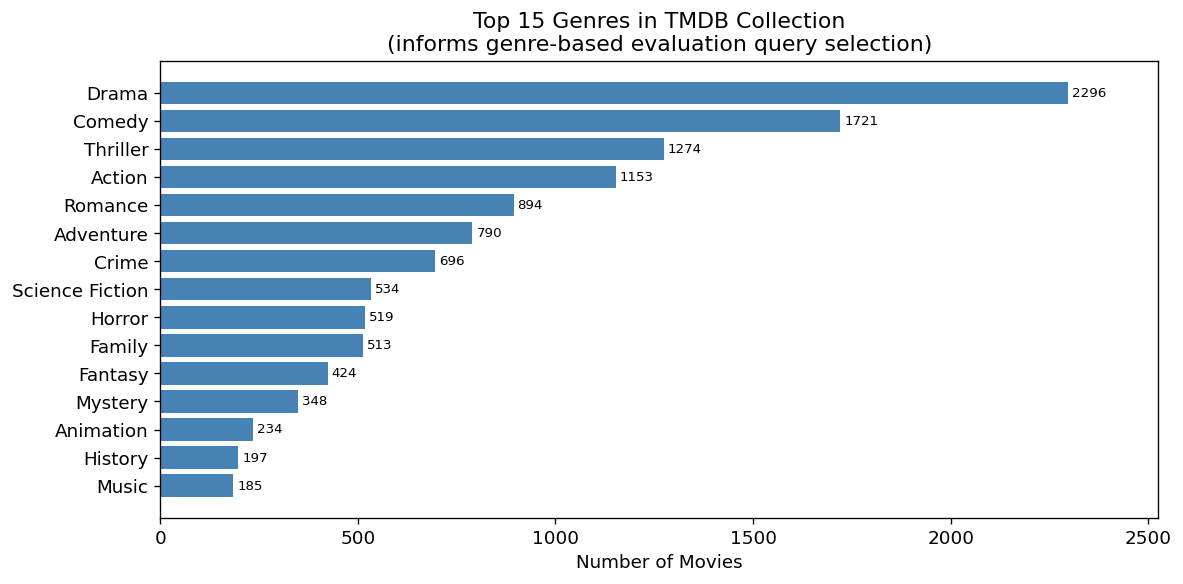

Figure saved: genre_distribution.png


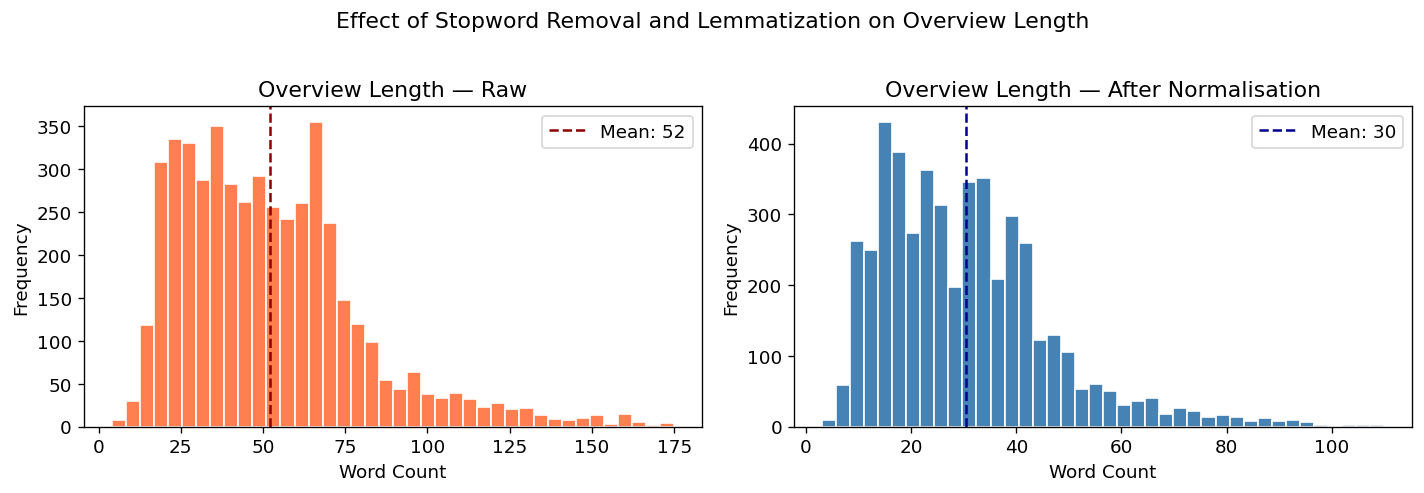

Figure saved: overview_length_distribution.png
Average reduction in overview length: 52 → 30 words (42% reduction)


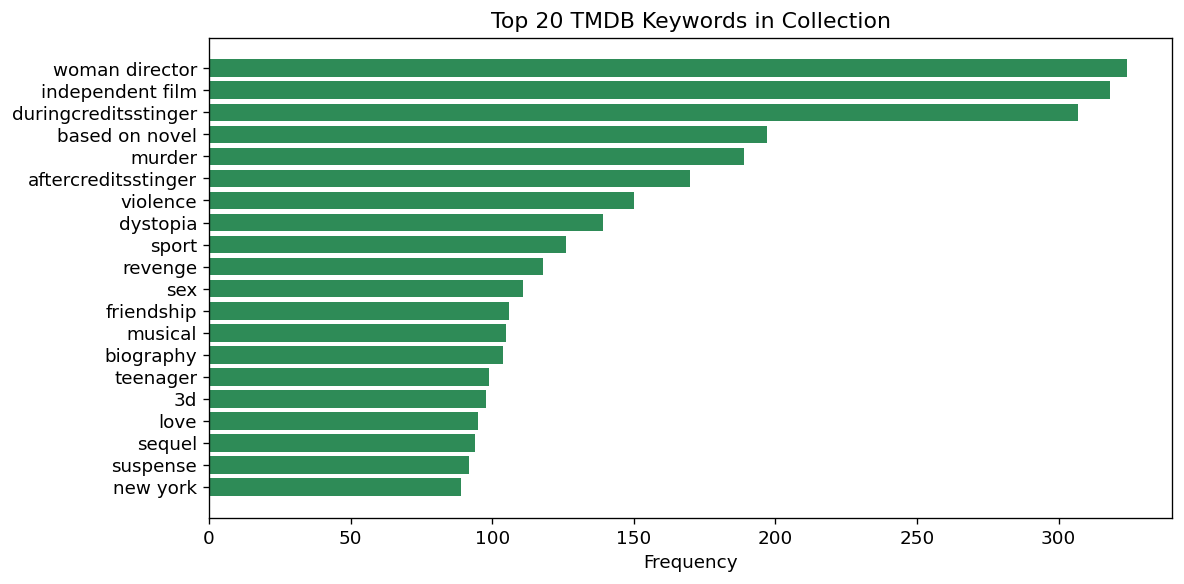

Figure saved: top_keywords.png


In [12]:
# Visualisation 1: Genre distribution
all_genres = [g for genres in merged_df['genres'] for g in genres]
genre_counts = Counter(all_genres).most_common(15)
genres_labels, genre_vals = zip(*genre_counts)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(genres_labels[::-1], genre_vals[::-1], color='steelblue')
ax.set_xlabel('Number of Movies')
ax.set_title('Top 15 Genres in TMDB Collection\n(informs genre-based evaluation query selection)')
ax.set_xlim(0, max(genre_vals) * 1.1)
for i, v in enumerate(genre_vals[::-1]):
    ax.text(v + 10, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: genre_distribution.png')

# Visualisation 2: Overview length distribution
raw_lengths = merged_df['overview'].dropna().apply(lambda x: len(x.split()))
norm_lengths = documents_df['overview'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_lengths, bins=40, color='coral', edgecolor='white')
axes[0].axvline(raw_lengths.mean(), color='darkred', linestyle='--', label=f'Mean: {raw_lengths.mean():.0f}')
axes[0].set_title('Overview Length — Raw')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(norm_lengths, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(norm_lengths.mean(), color='darkblue', linestyle='--', label=f'Mean: {norm_lengths.mean():.0f}')
axes[1].set_title('Overview Length — After Normalisation')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Effect of Stopword Removal and Lemmatization on Overview Length', y=1.02)
plt.tight_layout()
plt.savefig('overview_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: overview_length_distribution.png')
print(
    f'Average reduction in overview length: {raw_lengths.mean():.0f} → {norm_lengths.mean():.0f} words '
    f'({((raw_lengths.mean()-norm_lengths.mean())/raw_lengths.mean()*100):.0f}% reduction)'
)

# Visualisation 3: Top keywords
all_keywords = [k for kws in merged_df['keywords'] for k in kws]
kw_counts = Counter(all_keywords).most_common(20)
kw_labels, kw_vals = zip(*kw_counts)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(kw_labels[::-1], kw_vals[::-1], color='seagreen')
ax.set_xlabel('Frequency')
ax.set_title('Top 20 TMDB Keywords in Collection')
plt.tight_layout()
plt.savefig('top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: top_keywords.png')

## 9. Indexing Module

A single inverted index is built on weighted_text and shared
across all four BM25 configurations, no duplication of data
structures.

IDF uses the Robertson-Sparck Jones formula which avoids negative
values for very common terms. The sample values illustrate the
discriminative power of the index: 'nolan' (df=18, idf=5.56) and
'spielberg' (df=29, idf=5.09) are highly discriminative, rare
enough to strongly identify relevant documents. 'action' (df=1228,
idf=1.36) is more common and contributes less. 'the' has
idf=0.0 because it was removed as a stopword during normalisation
and never entered the index.

The high IDF terms (barbossa, swann, barsoom) are character names
from specific films, extremely rare and therefore maximally
discriminative, exactly as expected.

In [13]:
prepared_df = documents_df.copy()
print('\nUsing documents_df from memory.')
print(f'Collection size: {len(prepared_df):,} documents')
print(f'Columns: {list(prepared_df.columns)}')

# Baseline index on weighted_text
inverted_index = defaultdict(list)
tf_store = {}
doc_lengths = {}

for idx, row in prepared_df.iterrows():
    tokens = str(row['weighted_text']).split()
    tf_store[idx] = Counter(tokens)
    doc_lengths[idx] = len(tokens)
    for term in set(tokens):
        inverted_index[term].append(idx)

avgdl = np.mean(list(doc_lengths.values()))

print('\n=== Baseline Index Stats ===')
print(f'Vocabulary size:         {len(inverted_index):,} unique terms')
print(f'Average document length: {avgdl:.1f} tokens')
print(f'Max document length:     {max(doc_lengths.values())} tokens')
print(f'Min document length:     {min(doc_lengths.values())} tokens')

N = len(prepared_df)
idf_store = {}
for term, doc_list in inverted_index.items():
    df_t = len(doc_list)
    idf_store[term] = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

print('\n=== Sample IDF values ===')
for sample in ['love', 'nolan', 'action', 'the', 'spielberg']:
    val = idf_store.get(sample, 0.0)
    df = len(inverted_index.get(sample, []))
    print(f'  {sample:<15} df={df:>5}   idf={val:.4f}')

print('\nHigh IDF terms (rare, discriminative):')
for term, val in sorted(idf_store.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {term:<20} idf={val:.4f}')

print('\nLow IDF terms (common, less discriminative):')
for term, val in sorted(idf_store.items(), key=lambda x: x[1])[:5]:
    print(f'  {term:<20} idf={val:.4f}')


Using documents_df from memory.
Collection size: 4,799 documents
Columns: ['title', 'overview', 'genres', 'keywords', 'cast', 'director', 'tagline', 'weighted_text', 'id', 'title_raw', 'vote_average', 'vote_count', 'popularity']

=== Baseline Index Stats ===
Vocabulary size:         35,212 unique terms
Average document length: 110.5 tokens
Max document length:     421 tokens
Min document length:     9 tokens

=== Sample IDF values ===
  love            df=  806   idf=1.7837
  nolan           df=   18   idf=5.5586
  action          df= 1228   idf=1.3628
  the             df=    0   idf=0.0000
  spielberg       df=   29   idf=5.0920

High IDF terms (rare, discriminative):
  barbossa             idf=8.0709
  swann                idf=8.0709
  seydoux              idf=8.0709
  peel                 idf=8.0709
  barsoom              idf=8.0709

Low IDF terms (common, less discriminative):
  drama                idf=0.7290
  comedy               idf=1.0167
  thriller             idf=1.3128
  

## 10. Retrieval Module

### 10.1 Index Construction

Three separate index structures are built here.

The overview-only index supports Configuration 1 — BM25 on plot
summaries only. The per-field indexes support Configurations 3
and 4 — Linear Field-Score Combination and FreqComb both need
term frequencies broken down by field.

FreqComb requires a global IDF that treats each
document as a whole rather than per-field, this is computed
from global_doc_freq which tracks which documents contain each
term across all fields combined.

The field stats confirm the design rationale: genres has only
22 unique terms (very short, unambiguous) while overview has
18,960 (rich but noisy). Director averages 2.1 tokens per
document, small and discriminative, justifying its
weight of 2.

In [14]:
# Overview-only index
overview_tf = {}
overview_inv = defaultdict(list)
overview_lens = {}

for idx, row in prepared_df.iterrows():
    tokens = str(row['overview']).split()
    overview_tf[idx] = Counter(tokens)
    overview_lens[idx] = len(tokens)
    for term in set(tokens):
        overview_inv[term].append(idx)

overview_avgdl = np.mean(list(overview_lens.values()))
overview_idf = {}
for term, doc_list in overview_inv.items():
    df_t = len(doc_list)
    overview_idf[term] = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

# Per-field indexes for linear and FreqComb
field_tf = {f: {} for f in FIELDS}
field_inv_idx = {f: defaultdict(list) for f in FIELDS}
field_avgdl = {}
field_idf = {f: {} for f in FIELDS}

for field in FIELDS:
    lengths = []
    for idx, row in prepared_df.iterrows():
        tokens = str(row[field]).split() if pd.notna(row[field]) else []
        field_tf[field][idx] = Counter(tokens)
        lengths.append(len(tokens))
        for term in set(tokens):
            field_inv_idx[field][term].append(idx)
    field_avgdl[field] = np.mean(lengths) if lengths else 1.0
    for term, doc_list in field_inv_idx[field].items():
        df_t = len(doc_list)
        field_idf[field][term] = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

print('\nPer-field index built.')
print(f'{"Field":<12} {"Avg tokens":>12} {"Vocab size":>12} {"Weight":>8}')
print('-' * 48)
for f in FIELDS:
    print(f'{f:<12} {field_avgdl[f]:>12.1f} {len(field_idf[f]):>12,} {FIELD_WEIGHTS[f]:>8}')

# Global IDF for FreqComb
global_doc_freq = defaultdict(set)
for f in FIELDS:
    for doc_id, counter in field_tf[f].items():
        for term in counter:
            global_doc_freq[term].add(doc_id)

global_idf = {}
for term, doc_set in global_doc_freq.items():
    df_t = len(doc_set)
    global_idf[term] = math.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

weighted_doc_len = {
    idx: sum(FIELD_WEIGHTS[f] * sum(field_tf[f][idx].values()) for f in FIELDS)
    for idx in prepared_df.index
}
avg_weighted_dl = np.mean(list(weighted_doc_len.values()))


Per-field index built.
Field          Avg tokens   Vocab size   Weight
------------------------------------------------
title                 2.0        4,281        3
overview             30.4       18,960        1
genres                2.6           22        2
keywords             10.9        6,887      1.5
cast                 19.6       15,831      1.5
director              2.1        2,890        2
tagline               3.5        3,590        1


### 10.2 Retrieval Functions

Four BM25 retrieval functions, all normalising the query
identically before scoring.

`search_overview` scores on plot summary only, the weakest
baseline, included to quantify how much structured metadata
fields contribute.

`search_baseline` scores on weighted_text , all fields
concatenated with token repetition approximating field weights.

`search_linear` scores BM25 independently per field then takes
a weighted sum. This applies TF saturation separately per field,
which inflates scores for terms that appear across multiple fields
— the key flaw identified by Robertson et al. (2004).

`search_freqcomb` aggregates weighted term frequencies across
all fields first, then applies a single BM25 scoring curve.
This preserves non-linear saturation across the combined field
evidence and is the principled fix to linear combination's
limitation.

In [15]:
def search_overview(query, top_k=10):
    q_terms = normalise(query).split()
    if not q_terms:
        return []
    candidate_ids = set()
    for term in q_terms:
        candidate_ids.update(overview_inv.get(term, []))

    scores = []
    for doc_id in candidate_ids:
        score = 0.0
        dl = overview_lens[doc_id]
        for term in q_terms:
            tf = overview_tf[doc_id].get(term, 0)
            if tf == 0:
                continue
            score += bm25_score(tf, overview_idf.get(term, 0.0), dl, overview_avgdl)
        if score > 0:
            scores.append((int(doc_id), float(score)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

def search_baseline(query, top_k=10):
    q_terms = normalise(query).split()
    if not q_terms:
        return []
    candidate_ids = set()
    for term in q_terms:
        candidate_ids.update(inverted_index.get(term, []))

    scores = []
    for doc_id in candidate_ids:
        score = 0.0
        dl = doc_lengths[doc_id]
        for term in q_terms:
            tf = tf_store[doc_id].get(term, 0)
            if tf == 0:
                continue
            score += bm25_score(tf, idf_store.get(term, 0.0), dl, avgdl)
        if score > 0:
            scores.append((int(doc_id), float(score)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

def _bm25_term_field(term, field, doc_id):
    tf = field_tf[field][doc_id].get(term, 0)
    if tf == 0:
        return 0.0
    dl = sum(field_tf[field][doc_id].values())
    avgdl_f = max(field_avgdl[field], 1.0)
    idf_val = field_idf[field].get(term, 0.0)
    return bm25_score(tf, idf_val, dl, avgdl_f)

def search_linear(query, top_k=10):
    q_terms = normalise(query).split()
    if not q_terms:
        return []

    candidate_ids = set()
    for term in q_terms:
        for f in FIELDS:
            candidate_ids.update(field_inv_idx[f].get(term, []))

    scores = []
    for doc_id in candidate_ids:
        score = sum(
            FIELD_WEIGHTS[f] * _bm25_term_field(term, f, doc_id)
            for term in q_terms for f in FIELDS
        )
        if score > 0:
            scores.append((int(doc_id), float(score)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

def search_freqcomb(query, top_k=10):
    q_terms = normalise(query).split()
    if not q_terms:
        return []

    candidate_ids = set()
    for term in q_terms:
        candidate_ids.update(global_doc_freq.get(term, set()))

    scores = []
    for doc_id in candidate_ids:
        score = 0.0
        dl = weighted_doc_len[doc_id]
        for term in q_terms:
            agg_tf = sum(FIELD_WEIGHTS[f] * field_tf[f][doc_id].get(term, 0) for f in FIELDS)
            if agg_tf == 0:
                continue
            score += bm25_score(agg_tf, global_idf.get(term, 0.0), dl, avg_weighted_dl)
        if score > 0:
            scores.append((int(doc_id), float(score)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

### 10.3 Score Adjustment Layer

A post-ranking adjustment that shows BM25 relevance scores with
popularity metadata signals.

The adjustment multiplies the BM25 score by a small factor
that comes from vote average, vote count confidence, and TMDB
popularity. Alpha=0.1 keeps the adjustment subtle, a maximum
10% boost for the most popular, highly-rated films, so BM25
ranking is not fundamentally changed, only slightly refined.

`rank_results` is the unified interface over all four methods.
It normalises the query, dispatches to the appropriate search
function, applies score adjustment, re-sorts and assigns final
ranks. All evaluation and demo code calls this function rather
than the search functions directly.

In [16]:
def score_adjust(bm25_score, vote_avg, vote_count, popularity, alpha=0.1):
    if bm25_score <= 0:
        return 0.0
    vote_signal = (vote_avg / 10.0) if vote_avg else 0.5
    confidence  = min(vote_count / 50, 1.0) if vote_count else 0.0
    pop_signal  = min(math.log1p(popularity) / 10.0, 1.0) if popularity else 0.0
    metadata_signal = (vote_signal * confidence + pop_signal) / 2.0
    return bm25_score * (1.0 + alpha * metadata_signal)

def rank_results(query, method='freqcomb', top_k=10):
    dispatch = {
        'overview': search_overview,
        'baseline': search_baseline,
        'linear': search_linear,
        'freqcomb': search_freqcomb,
    }
    if method not in dispatch:
        raise ValueError(f"Unknown method '{method}'. Choose: {list(dispatch.keys())}")

    raw = dispatch[method](query, top_k=top_k)
    output = []
    for doc_id, bm25_sc in raw:
        row = prepared_df.loc[doc_id]
        adj_score = score_adjust(bm25_sc, row['vote_average'], row['vote_count'], row['popularity'])
        ov = str(row.get('overview', ''))
        output.append({
            'rank'            : 0,
            'doc_id'          : int(doc_id),
            'title'           : row['title_raw'],
            'score'           : round(float(adj_score), 4),
            'overview_snippet': ov[:120] + '...' if len(ov) > 120 else ov,
        })

    output.sort(key=lambda x: x['score'], reverse=True)
    output = output[:top_k]
    for i, r in enumerate(output, 1):
        r['rank'] = i

    return output

### 10.4 Retrieval Checks

Check to verify all four retrieval functions are
working correctly before evaluation.

The cross-method comparison shows the expected pattern: overview
only struggles with entity queries ('christopher nolan' returns
Bruce Almighty and Must Love Dogs — films with no director
signal), while FreqComb correctly surfaces Nolan films by
aggregating the director field evidence. Linear combination
returns 'Stranded' for the descriptive query , a vocabulary
match rather than a thematically relevant result, illustrating
the limitation that FreqComb addresses.

In [17]:
print('\nOverview-only — romantic comedy (top 5):')
for doc_id, score in search_overview('romantic comedy', top_k=5):
    print(f'  {prepared_df.loc[doc_id, "title_raw"]:<40} {score:.4f}')

print('\nBaseline BM25 — romantic comedy (top 5):')
for doc_id, score in search_baseline('romantic comedy', top_k=5):
    print(f'  {prepared_df.loc[doc_id, "title_raw"]:<40} {score:.4f}')

print('\nLinear Field-Score Combination — romantic comedy (top 5):')
for doc_id, score in search_linear('romantic comedy', top_k=5):
    print(f'  {prepared_df.loc[doc_id, "title_raw"]:<40} {score:.4f}')

print('\nFreqComb — christopher nolan (top 5):')
for doc_id, score in search_freqcomb('christopher nolan', top_k=5):
    print(f'  {prepared_df.loc[doc_id, "title_raw"]:<40} {score:.4f}')

# Cross-method comparison
test_queries = [
    ('romantic comedy', 'genre query'),
    ('christopher nolan', 'entity query — director'),
    ('survival stranded', 'descriptive query'),
]

print('\n=== Cross-method comparison (top 2 per query) ===')
for query, label in test_queries:
    print(f'\nQuery: "{query}" [{label}]')
    print(f'  {"Method":<12} {"Rank 1":<35} {"Rank 2":<35}')
    print('  ' + '-' * 80)
    for method in ['overview', 'baseline', 'linear', 'freqcomb']:
        res = rank_results(query, method=method, top_k=2)
        r1 = res[0]['title'] if len(res) > 0 else 'n/a'
        r2 = res[1]['title'] if len(res) > 1 else 'n/a'
        print(f'  {method:<12} {r1:<35} {r2:<35}')


Overview-only — romantic comedy (top 5):
  Date Movie                               11.2266
  16 to Life                               10.5929
  Christmas Mail                           10.5929
  Midnight in Paris                        10.2088
  One Day                                  9.6822

Baseline BM25 — romantic comedy (top 5):
  The Broken Hearts Club: A Romantic Comedy 9.2855
  Dry Spell                                8.2256
  Never Again                              8.1893
  Hitch                                    8.1686
  Shaun of the Dead                        7.9757

Linear Field-Score Combination — romantic comedy (top 5):
  The Broken Hearts Club: A Romantic Comedy 41.3794
  The Original Kings of Comedy             26.2316
  Road Hard                                23.1388
  Never Again                              22.1056
  Hitch                                    22.0806

FreqComb — christopher nolan (top 5):
  Insomnia                                 12.5455
  The 

## 11. Field Weight Sensitivity Analysis

Tests FreqComb under four different weight configurations to
verify the chosen weights are not arbitrarily tuned.

Results show that entity and genre queries are stable across
configurations- 'christopher nolan' returns Insomnia under three of
four configurations, and 'animated family' returns Rugrats Go
Wild under all four. This confirms rankings are driven by term
matching, not weight magnitude.

Divergence appears on descriptive queries like 'action thriller'
and 'steven spielberg' under the overview-heavy configuration, where
reducing title and director weights loses the field specificity
that makes entity retrieval precise. This validates the
chosen weights.

In [18]:
weight_configs = {
    'Chosen weights   (title=3, genre=2, dir=2)': {'title':3,'overview':1,'genres':2,'keywords':1.5,'cast':1.5,'director':2,'tagline':1},
    'Title-heavy      (title=5, genre=2, dir=2)': {'title':5,'overview':1,'genres':2,'keywords':1.5,'cast':1.5,'director':2,'tagline':1},
    'Overview-heavy   (title=2, genre=1, dir=1)': {'title':2,'overview':3,'genres':1,'keywords':1.0,'cast':1.0,'director':1,'tagline':1},
    'Uniform weights  (all=1)':                   {'title':1,'overview':1,'genres':1,'keywords':1,'cast':1,'director':1,'tagline':1},
}

ablation_queries = [
    'christopher nolan', 'romantic comedy', 'space survival',
    'steven spielberg', 'action thriller', 'animated family'
]

def freqcomb_custom_weights(query, weights, top_k=5):
    q_terms = normalise(query).split()
    if not q_terms:
        return []

    fields = list(weights.keys())
    wdl = {
        idx: sum(weights[f] * sum(field_tf[f][idx].values()) for f in fields)
        for idx in prepared_df.index
    }
    avg_wdl = np.mean(list(wdl.values()))

    gdf = defaultdict(set)
    for f in fields:
        for doc_id, counter in field_tf[f].items():
            for term in counter:
                gdf[term].add(doc_id)

    g_idf = {
        t: math.log((N - len(ds) + 0.5) / (len(ds) + 0.5) + 1)
        for t, ds in gdf.items()
    }

    cands = set()
    for term in q_terms:
        cands.update(gdf.get(term, set()))

    scores = []
    for doc_id in cands:
        score = 0.0
        dl = wdl[doc_id]
        for term in q_terms:
            agg = sum(weights[f] * field_tf[f][doc_id].get(term, 0) for f in fields)
            if agg == 0:
                continue
            score += bm25_score(agg, g_idf.get(term, 0.0), dl, avg_wdl)
        if score > 0:
            scores.append((int(doc_id), float(score)))

    scores.sort(key=lambda x: x[1], reverse=True)
    return [prepared_df.loc[d, 'title_raw'] for d, _ in scores[:top_k]]

print('\n=== Field Weight Ablation — Top-1 result per query/config ===')
print(f'{"Query":<25}', end='')
cfg_names = list(weight_configs.keys())
for name in cfg_names:
    print(f'  {name[:20]:<22}', end='')
print()
print('-' * 115)

for query in ablation_queries:
    print(f'{query:<25}', end='')
    for name, wts in weight_configs.items():
        top1 = freqcomb_custom_weights(query, wts, top_k=1)
        val = top1[0][:20] if top1 else 'n/a'
        print(f'  {val:<22}', end='')
    print()

print('\nInterpretation: Consistent top-1 results across configs indicate')
print('the ranking is driven by term matching, not weight magnitude.')
print('Divergence on descriptive queries is expected and reveals the')
print('vocabulary mismatch regime where BM25 is weakest.')



=== Field Weight Ablation — Top-1 result per query/config ===
Query                      Chosen weights   (ti    Title-heavy      (ti    Overview-heavy   (ti    Uniform weights  (al  
-------------------------------------------------------------------------------------------------------------------
christopher nolan          Insomnia                Insomnia                Must Love Dogs          Insomnia              
romantic comedy            The Broken Hearts Cl    The Broken Hearts Cl    16 to Life              The Broken Hearts Cl  
space survival             The Martian             The Martian             The Fifth Element       The Martian           
steven spielberg           The Lost World: Jura    The Lost World: Jura    Hook                    Hook                  
action thriller            Jimmy and Judy          The Transporter Refu    Hitman                  The Transporter Refu  
animated family            Rugrats Go Wild         Rugrats Go Wild         Rugrats Go Wil

## 12. Evaluation Module

### 12.1 Query Set and Relevance Pool

30 queries across three types:
- 10 genre-based
- 10 entity-based
- 10 mixed/descriptive

The mix makes sure evaluation
covers the whole range of search behaviours the system is
expected to handle.

The pool is created by running all four BM25 methods on each
query (top-20 each) and taking the union. This gives arund 40
documents per query to annotate manually — standard pooling
methodology. Documents
outside the pool are assumed not relevant.

There is however a limitation with pool depth. 10 relevant documents across five queries
ranked below the top-20 cutoff and are therefore unreachable.
Recall figures for those queries represent a lower bound on true
recall. This does not affect Precision or NDCG scores.

In [19]:
QUERIES = [
    ('romantic comedy', 'genre'),
    ('action thriller', 'genre'),
    ('science fiction space', 'genre'),
    ('horror zombie', 'genre'),
    ('animated family', 'genre'),
    ('historical war drama', 'genre'),
    ('crime heist', 'genre'),
    ('superhero marvel', 'genre'),
    ('psychological thriller mystery', 'genre'),
    ('documentary biography', 'genre'),
    ('christopher nolan', 'entity'),
    ('steven spielberg', 'entity'),
    ('tom hanks', 'entity'),
    ('quentin tarantino', 'entity'),
    ('meryl streep', 'entity'),
    ('brad pitt', 'entity'),
    ('james bond spy', 'entity'),
    ('tim burton', 'entity'),
    ('martin scorsese', 'entity'),
    ('ridley scott', 'entity'),
    ('survival stranded alone', 'mixed'),
    ('time travel science fiction', 'mixed'),
    ('artificial intelligence robot', 'mixed'),
    ('coming of age teenager school', 'mixed'),
    ('heist bank robbery', 'mixed'),
    ('spy espionage cold war', 'mixed'),
    ('alien invasion earth', 'mixed'),
    ('forbidden love romance tragedy', 'mixed'),
    ('prison escape freedom', 'mixed'),
    ('boxing sport underdog', 'mixed'),
]

# Pool generation
pool = {}
for query, qtype in QUERIES:
    titles = set()
    for method in ['overview', 'baseline', 'linear', 'freqcomb']:
        for r in rank_results(query, method=method, top_k=20):
            titles.add(r['title'])
    pool[query] = titles

print(f'\nPool generated. Mean pool size per query: {np.mean([len(v) for v in pool.values()]):.1f} documents')
print(f'Total unique (query, title) pairs to annotate: {sum(len(v) for v in pool.values())}')


Pool generated. Mean pool size per query: 39.9 documents
Total unique (query, title) pairs to annotate: 1198


### 12.2 Relevance Judgements

Manual relevance grades for all 30 queries based on the pooled
results.

Grades: 2 = relevant, 1 = partially relevant, 0 = not
relevant (assumed for anything not listed).

Judgements were made by examining system output and TMDB metadata
directly. Only titles that appeared in the pool for a given query
are graded, documents outside the pool are assumed 0 following
standard pooling practice.

Mean of 14.5 relevant documents per query gives sufficient
density for meaningful NDCG and MAP computation across the
30-query set.

In [20]:
RELEVANCE = {
    'romantic comedy': {
        'Hitch': 2, 'Pretty Woman': 2, 'What Happens in Vegas': 1,
        "There's Something About Mary": 2, "You've Got Mail": 2,
        'Failure to Launch': 1, 'Two Weeks Notice': 2, 'Music and Lyrics': 2,
        'Four Christmases': 1, 'Just Like Heaven': 1, 'Sliding Doors': 1,
        "She's Out of My League": 1, 'The Ugly Truth': 2, '50 First Dates': 2,
        'One Day': 1, 'To Rome with Love': 1, 'Midnight in Paris': 1,
        'The Broken Hearts Club: A Romantic Comedy': 2,
    },
    'action thriller': {
        'Die Hard: With a Vengeance': 2, 'Taken': 2, 'Looper': 1,
        'Jason Bourne': 2, 'Flightplan': 1, 'The Bourne Legacy': 2,
        'Hitman': 1, 'Lethal Weapon 4': 1, 'The 6th Day': 1,
        'I Am Number Four': 1, 'The Transporter Refueled': 1,
        'The Sweeney': 1, 'Last Action Hero': 1,
    },
    'science fiction space': {
        'Gravity': 2, 'The Martian': 2, 'Avatar': 2,
        '2001: A Space Odyssey': 2, 'Alien': 2, 'Aliens': 2,
        'Ender\'s Game': 2, 'Gattaca': 2, 'Contact': 2,
        'Star Trek Beyond': 2, 'Lost in Space': 1, 'Mission to Mars': 1,
        'Space Cowboys': 1, 'Zathura: A Space Adventure': 1,
        'Moonraker': 1, 'Lifeforce': 1, 'Silent Running': 2,
        'Lockout': 1, 'Mars Attacks!': 1,
    },
    'horror zombie': {
        'World War Z': 2, 'Zombieland': 2, 'Dawn of the Dead': 2,
        'Shaun of the Dead': 2, 'Warm Bodies': 1,
        'Day of the Dead': 2, 'Land of the Dead': 2, 'Diary of the Dead': 2,
        'Dead Snow': 2, 'Night of the Living Dead': 2,
        'Pride and Prejudice and Zombies': 1, 'Maggie': 1,
        'Pontypool': 2, 'Survival of the Dead': 1,
        'ZMD: Zombies of Mass Destruction': 1,
    },
    'animated family': {
        'Madagascar': 2, 'Antz': 2, 'Anastasia': 2, 'Pocahontas': 2,
        'Stuart Little': 2, 'The Croods': 2, "The Curse of the Were-Rabbit": 2,
        'Ice Age: The Meltdown': 2, "Surf's Up": 2, 'Valiant': 1,
        'Barnyard': 1, 'Enchanted': 2, 'Mary Poppins': 1,
    },
    'historical war drama': {
        'Fury': 2, 'Platoon': 2, 'Patton': 1,
        'Glory': 2, 'Enemy at the Gates': 2, 'Hart\'s War': 1,
        'Downfall': 2, 'Unbroken': 2, 'Lincoln': 2,
        'Tae Guk Gi: The Brotherhood of War': 2,
        "Charlie Wilson's War": 1, 'The Flowers of War': 1,
        'In the Land of Blood and Honey': 1, 'War Horse': 1,
        'The New World': 1,
    },
    'crime heist': {
        'Inside Man': 2, 'Now You See Me': 2, "Ocean's Thirteen": 1,
        'The Score': 2, 'Heist': 2, 'The Usual Suspects': 2,
        'Drive': 1, 'Reservoir Dogs': 2, 'The Good Thief': 2,
        'Tower Heist': 1, 'Trance': 1, 'Triple 9': 1,
        'Fast Five': 1, 'Dead Man Down': 1, 'Sexy Beast': 2,
    },
    'superhero marvel': {
        'The Avengers': 2, 'Iron Man': 2, 'Thor': 2,
        'Captain America: The First Avenger': 2,
        'Captain America: The Winter Soldier': 2,
        'Ant-Man': 2, 'Iron Man 3': 2, 'Avengers: Age of Ultron': 2,
        'Thor: The Dark World': 1, 'Spider-Man': 2, 'Spider-Man 2': 2,
        'The Incredible Hulk': 2, 'Iron Man 2': 2,
        'Captain America: Civil War': 2, 'X-Men': 1, 'X2': 1,
        'X-Men Origins: Wolverine': 1, 'The Wolverine': 1,
        'Fantastic Four': 1, 'Hancock': 1,
    },
    'psychological thriller mystery': {
        'The Sixth Sense': 2, 'The Silence of the Lambs': 2,
        'Match Point': 2, 'Secret Window': 1, 'One Hour Photo': 2,
        'Stoker': 2, 'Swimming Pool': 2, 'Stir of Echoes': 1,
        'Non-Stop': 1, 'The Number 23': 1, 'Mindhunters': 1,
        'The Skeleton Key': 1, 'Buried': 1, 'Case 39': 1,
        'The Gift': 1, 'Antiviral': 1,
    },
    'documentary biography': {
        'An Inconvenient Truth': 2, 'Roger & Me': 2, 'Sicko': 2,
        'The Theory of Everything': 2, 'The Pianist': 2,
        'Control': 2, 'Basquiat': 2, 'Coal Miner\'s Daughter': 2,
        'Born on the Fourth of July': 2, 'The Greatest Movie Ever Sold': 1,
        'Freakonomics': 1, 'Mad Hot Ballroom': 1,
    },
    'christopher nolan': {
        'Inception': 2, 'The Dark Knight': 2, 'Interstellar': 2,
        'Memento': 2, 'Batman Begins': 2, 'The Dark Knight Rises': 2,
        'The Prestige': 2, 'Insomnia': 2,
    },
    'steven spielberg': {
        'Saving Private Ryan': 2, "Schindler's List": 2, 'Jurassic Park': 2,
        'Munich': 2, 'Lincoln': 2, 'Catch Me If You Can': 2,
        'Indiana Jones and the Kingdom of the Crystal Skull': 2,
        'The Terminal': 1, 'War of the Worlds': 1, 'War Horse': 1,
        'Hook': 1, 'Amistad': 2, 'Minority Report': 2,
        'Close Encounters of the Third Kind': 2,
        'Indiana Jones and the Last Crusade': 2,
        'Indiana Jones and the Temple of Doom': 2,
        'Raiders of the Lost Ark': 2, 'Jaws': 2,
        'The Lost World: Jurassic Park': 1,
    },
    'tom hanks': {
        'Cast Away': 2, 'Philadelphia': 2, 'Saving Private Ryan': 2,
        'Big': 2, 'Captain Phillips': 2,
        "Charlie Wilson's War": 1, 'Angels & Demons': 1,
        'Toy Story': 2, 'Toy Story 2': 2, 'Toy Story 3': 2,
        'Catch Me If You Can': 2, 'Cloud Atlas': 1,
        'Extremely Loud & Incredibly Close': 1, 'Larry Crowne': 1,
        'The Polar Express': 1, 'Splash': 1,
    },
    'quentin tarantino': {
        'Pulp Fiction': 2, 'Kill Bill: Vol. 1': 2, 'Django Unchained': 2,
        'Inglourious Basterds': 2, 'Reservoir Dogs': 2, 'Jackie Brown': 2,
        'The Hateful Eight': 2, 'Kill Bill: Vol. 2': 2,
        'Four Rooms': 1, 'From Dusk Till Dawn': 1, 'Grindhouse': 1,
    },
    'meryl streep': {
        'The Devil Wears Prada': 2, 'Doubt': 2, 'Julie & Julia': 2,
        'August: Osage County': 2, 'Adaptation.': 1, 'Mamma Mia!': 1,
        'Death Becomes Her': 1, 'Into the Woods': 1,
        'The Bridges of Madison County': 2, 'The Hours': 2,
        "It's Complicated": 1, 'The Deer Hunter': 1,
    },
    'brad pitt': {
        'Fight Club': 2, 'Se7en': 2, 'Inglourious Basterds': 2,
        'The Curious Case of Benjamin Button': 2, "Ocean's Eleven": 2,
        'Moneyball': 2, 'Mr. & Mrs. Smith': 2, 'Troy': 2,
        "Ocean's Twelve": 1, "Ocean's Thirteen": 1,
        '12 Years a Slave': 1, 'Fury': 1, 'Babel': 1, 'Snatch': 2,
        'Interview with the Vampire': 1, 'Sleepers': 1,
        'Seven Years in Tibet': 1, 'Spy Game': 1,
    },
    'james bond spy': {
        'GoldenEye': 2, 'Skyfall': 2, 'Spectre': 2, 'Quantum of Solace': 2,
        'Licence to Kill': 1, 'The Living Daylights': 1,
        'Moonraker': 1, 'Dr. No': 2, 'From Russia with Love': 2,
        'Thunderball': 2, 'You Only Live Twice': 1,
        'A View to a Kill': 1, 'For Your Eyes Only': 1,
        'Diamonds Are Forever': 1, 'Live and Let Die': 1,
        'The Spy Who Loved Me': 1, 'On Her Majesty\'s Secret Service': 1,
        'Octopussy': 1, 'Tinker Tailor Soldier Spy': 1,
    },
    'tim burton': {
        'Batman': 2, 'Batman Returns': 2, 'Edward Scissorhands': 2,
        'Beetlejuice': 2, 'Big Fish': 2, 'Big Eyes': 2,
        'Charlie and the Chocolate Factory': 2, 'Dark Shadows': 2,
        'Alice in Wonderland': 2, 'Ed Wood': 2, 'Mars Attacks!': 1,
        'Planet of the Apes': 1, 'Frankenweenie': 2, 'Corpse Bride': 2,
    },
    'martin scorsese': {
        'The Departed': 2, 'Gangs of New York': 2, 'The Wolf of Wall Street': 2,
        'Shutter Island': 2, 'Casino': 2, 'Taxi Driver': 2,
        'The Aviator': 2, 'Hugo': 2, 'Raging Bull': 2,
        'GoodFellas': 2, 'Cape Fear': 1, 'Kundun': 1,
        'The Age of Innocence': 1, 'Mean Streets': 2,
        'The Last Temptation of Christ': 1, 'Bringing Out the Dead': 1,
        'The Color of Money': 1,
    },
    'ridley scott': {
        'Gladiator': 2, 'The Martian': 2, 'Blade Runner': 2, 'Prometheus': 2,
        'American Gangster': 2, 'Black Hawk Down': 2, 'Kingdom of Heaven': 2,
        'Alien': 2, 'Robin Hood': 1, 'Black Rain': 1, 'Body of Lies': 1,
        'G.I. Jane': 1, 'A Good Year': 1, 'Exodus: Gods and Kings': 1,
        'The Counselor': 1, 'White Squall': 1,
    },
    'survival stranded alone': {
        '127 Hours': 2, 'Alive': 2, 'The Martian': 2,
        'I Am Legend': 2, 'The Grey': 2, 'Rescue Dawn': 2,
        'In the Heart of the Sea': 2, 'Eight Below': 1,
        'Pandorum': 1, 'Riddick': 1, 'Swept Away': 1,
    },
    'time travel science fiction': {
        'About Time': 2, 'The Butterfly Effect': 2, 'Timecop': 2,
        'Hot Tub Time Machine': 1, 'The Time Machine': 2,
        'In Time': 1, 'Men in Black 3': 1, 'Project Almanac': 1,
        'Timecrimes': 2, 'Kate & Leopold': 1, 'Timeline': 1,
        'Safety Not Guaranteed': 1, 'The Time Traveler\'s Wife': 1,
    },
    'artificial intelligence robot': {
        'A.I. Artificial Intelligence': 2, 'Ex Machina': 2, 'Her': 2,
        'I, Robot': 2, 'The Terminator': 2, 'Chappie': 2, 'Automata': 1,
        'Terminator 3: Rise of the Machines': 1,
        'Terminator Salvation': 1, 'Terminator Genisys': 1,
        'Bicentennial Man': 1, 'The Matrix': 2, 'WALL·E': 2,
        'Real Steel': 1, 'Surrogates': 1, 'Robot & Frank': 1,
    },
    'coming of age teenager school': {
        'The Perks of Being a Wallflower': 2, 'Dazed and Confused': 1,
        'American Pie': 2, 'Napoleon Dynamite': 2, 'School of Rock': 2,
        'An Education': 2, 'The Spectacular Now': 2, 'Diary of a Wimpy Kid': 1,
        'Chronicle': 1, 'Y Tu Mamá También': 2, 'Dope': 2,
        'The Wackness': 1, 'Saved!': 1, 'It\'s Kind of a Funny Story': 1,
    },
    'heist bank robbery': {
        'Inside Man': 2, 'The Town': 2, 'Set It Off': 1,
        'Bandits': 2, 'Heist': 2, 'The Bank Job': 2,
        'Tower Heist': 1, 'Now You See Me': 1,
        'Machine Gun McCain': 1, 'Killing Zoe': 1,
        'American Heist': 1, 'Dark Blue': 1,
    },
    'spy espionage cold war': {
        'Bridge of Spies': 2, 'Tinker Tailor Soldier Spy': 2, 'Salt': 2,
        "Charlie Wilson's War": 1, 'Mission: Impossible': 2,
        'Spy Game': 2, 'The Man from U.N.C.L.E.': 2,
        'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb': 2,
        'Topaz': 2, 'Torn Curtain': 2, 'This Means War': 1, 'Cypher': 1,
    },
    'alien invasion earth': {
        'Independence Day': 2, 'Battle: Los Angeles': 2, 'Signs': 2,
        'The 5th Wave': 1, 'Attack the Block': 2,
        'War of the Worlds': 2, 'Ender\'s Game': 1,
        'The Day the Earth Stood Still': 1, 'Cloverfield': 1,
        'The Host': 1, 'Independence Day: Resurgence': 1,
        'Alien': 1, 'Aliens': 1, 'After Earth': 1,
    },
    'forbidden love romance tragedy': {
        'Romeo + Juliet': 2, 'Her': 1, 'Titanic': 2,
        'Brokeback Mountain': 2, 'Doctor Zhivago': 2, 'Closer': 2,
        'West Side Story': 2, 'Twilight': 1,
        'Shakespeare in Love': 2, 'City of Angels': 1,
        'The Lake House': 1, 'Atonement': 2, 'Pocahontas': 1,
    },
    'prison escape freedom': {
        'The Shawshank Redemption': 2, 'Escape from Alcatraz': 2,
        'The Great Escape': 2, 'The Count of Monte Cristo': 2,
        'Escape Plan': 1, 'Escape from New York': 1,
        'Death Race': 1, 'Chicken Run': 2, 'Mandela: Long Walk to Freedom': 2,
        'Cry Freedom': 2, 'Public Enemies': 1,
    },
    'boxing sport underdog': {
        'Rocky': 2, 'Million Dollar Baby': 2, 'The Fighter': 2,
        'Creed': 2, 'Cinderella Man': 2, 'Southpaw': 2,
        'Real Steel': 1, 'Grudge Match': 1, 'The Hurricane': 2,
        'Ali': 2, 'Against the Ropes': 1, 'Snatch': 1,
    },
}

print(f'Relevance judgements: {len(RELEVANCE)} queries')
print(f'Mean relevant docs per query: {np.mean([sum(1 for g in v.values() if g >= 1) for v in RELEVANCE.values()]):.1f}')



Relevance judgements: 30 queries
Mean relevant docs per query: 14.5


### 12.3 Metric Functions

Six metrics, each capturing something different.

Precision@k tells you how many of the top results are
relevant.

Recall@10 tells you how much of the relevant set you
found.

F1@10 combines both. MAP looks at ranking quality across
the whole list rather than just the top-k cutoff.

NDCG@10 is the main one, it accounts for graded relevance
(2=relevant, 1=partial) and cares about position, so returning
a highly relevant film at rank 1 is better than returning it
at rank 10.

Anything graded 1 or 2 counts as relevant across all metrics.

In [21]:
# Metric functions
def get_grade(query, title):
    return RELEVANCE.get(query, {}).get(title, 0)

def precision_at_k(results, query, k):
    hits = sum(1 for r in results[:k] if get_grade(query, r['title']) >= 1)
    return hits / k if k else 0.0

def recall_at_k(results, query, k):
    total = sum(1 for g in RELEVANCE.get(query, {}).values() if g >= 1)
    if total == 0:
        return 0.0
    hits = sum(1 for r in results[:k] if get_grade(query, r['title']) >= 1)
    return hits / total

def f1_at_k(results, query, k):
    p = precision_at_k(results, query, k)
    r = recall_at_k(results, query, k)
    return 2 * p * r / (p + r) if p + r > 0 else 0.0

def average_precision(results, query):
    total = sum(1 for g in RELEVANCE.get(query, {}).values() if g >= 1)
    if total == 0:
        return 0.0
    hits, s = 0, 0.0
    for rank, r in enumerate(results, 1):
        if get_grade(query, r['title']) >= 1:
            hits += 1
            s += hits / rank
    return s / total

def ndcg_at_k(results, query, k):
    dcg = sum(get_grade(query, r['title']) / math.log2(i + 2) for i, r in enumerate(results[:k]))
    ideal = sorted(RELEVANCE.get(query, {}).values(), reverse=True)
    idcg = sum(g / math.log2(i + 2) for i, g in enumerate(ideal[:k]))
    return dcg / idcg if idcg > 0 else 0.0

print('Metric functions defined.')

Metric functions defined.


### 12.4 Run Evaluation

Runs all four methods across all 30 queries and computes the
six metrics for each. Results are stored in eval_results and
averaged into summary_df.

FreqComb wins on five of six metrics. The interesting result
is that Baseline BM25 edges FreqComb on NDCG@10 (0.5382 vs
0.5372) — a gap of just 0.001. This suggests token repetition
in weighted_text is a surprisingly effective approximation of
FreqComb's principled field weighting at this collection scale.

Note these numbers include the Score Adjustment Layer applied
via rank_results — popularity and vote signals contribute a
small boost on top of pure BM25 scores.

In [22]:
def evaluate_all(top_k=10):
    methods = ['overview', 'baseline', 'linear', 'freqcomb']
    store = {m: [] for m in methods}
    for query, qtype in QUERIES:
        for method in methods:
            res = rank_results(query, method=method, top_k=top_k)
            store[method].append({
                'query': query,
                'query_type': qtype,
                'method': method,
                'P@5': precision_at_k(res, query, 5),
                'P@10': precision_at_k(res, query, 10),
                'Recall@10': recall_at_k(res, query, 10),
                'F1@10': f1_at_k(res, query, 10),
                'MAP': average_precision(res, query),
                'NDCG@10': ndcg_at_k(res, query, 10),
            })
    return store

print('\nRunning evaluation across 30 queries x 4 methods...')
eval_results = evaluate_all(top_k=10)
print('Done.')

MLABELS = {
    'overview': 'Overview-only BM25',
    'baseline': 'Baseline BM25 (weighted_text)',
    'linear': 'Linear Field-Score Combination',
    'freqcomb': 'FreqComb',
}

METS = ['P@5', 'P@10', 'Recall@10', 'F1@10', 'MAP', 'NDCG@10']

rows = []
for m, label in MLABELS.items():
    row = {'Configuration': label}
    for met in METS:
        row[met] = round(np.mean([r[met] for r in eval_results[m]]), 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Configuration')

print('\n=== Mean Evaluation Metrics Across 30 Queries ===\n')
print(summary_df.to_string())

print('\n=== Best configuration per metric ===')
for col in METS:
    best = summary_df[col].idxmax()
    print(f'  {col:<12}: {best} ({summary_df.loc[best, col]:.4f})')


Running evaluation across 30 queries x 4 methods...
Done.

=== Mean Evaluation Metrics Across 30 Queries ===

                                   P@5    P@10  Recall@10   F1@10     MAP  NDCG@10
Configuration                                                                     
Overview-only BM25              0.3200  0.2533     0.1788  0.2080  0.1259   0.2432
Baseline BM25 (weighted_text)   0.6400  0.5833     0.4177  0.4805  0.3435   0.5382
Linear Field-Score Combination  0.5067  0.4733     0.3440  0.3929  0.2460   0.4158
FreqComb                        0.6800  0.5900     0.4211  0.4851  0.3527   0.5372

=== Best configuration per metric ===
  P@5         : FreqComb (0.6800)
  P@10        : FreqComb (0.5900)
  Recall@10   : FreqComb (0.4211)
  F1@10       : FreqComb (0.4851)
  MAP         : FreqComb (0.3527)
  NDCG@10     : Baseline BM25 (weighted_text) (0.5382)


### 12.5 Statistical Testing

Wilcoxon signed-rank test comparing FreqComb against each
baseline on per-query NDCG@10. We use Wilcoxon not  
a t-test because the scores aren't normally distributed and
n=30 is small.

FreqComb significantly beats Overview-only (p=0.0001) and
Linear Combination (p=0.0039). The gap with Baseline BM25
is not significant (p=0.59) — which makes sense given they
differ by only 0.001 NDCG.

The query type breakdown shows entity queries are where
structured fields matter most. Overview-only nearly falls
apart on entity queries (P@5=0.14) because it has no
director or cast field to match on.

In [23]:
# Wilcoxon
print('\n=== Wilcoxon Signed-Rank Test: FreqComb vs each baseline ===')
print('Null hypothesis: no difference in per-query NDCG@10 distributions')
print('Alpha = 0.05, two-sided\n')
print(f'{"Comparison":<45} {"W stat":>8}  {"p-value":>10}  {"Significant?":>14}')
print('-' * 80)

fc_scores = [r['NDCG@10'] for r in eval_results['freqcomb']]
for method in ['overview', 'baseline', 'linear']:
    other_scores = [r['NDCG@10'] for r in eval_results[method]]
    diffs = [a - b for a, b in zip(fc_scores, other_scores)]
    if all(d == 0 for d in diffs):
        print(f'  FreqComb vs {MLABELS[method]:<30} identical scores — no test')
        continue
    stat, p = wilcoxon(fc_scores, other_scores, alternative='two-sided')
    sig = 'YES *' if p < 0.05 else 'no'
    label = f'FreqComb vs {MLABELS[method]}'
    print(f'  {label:<43} {stat:>8.2f}  {p:>10.4f}  {sig:>14}')

print('\nNote: significance at p<0.05 means the observed difference is unlikely')
print('to have arisen by chance across the 30 queries.')

# By query type
def by_type(metric='NDCG@10'):
    rows = []
    for m, label in MLABELS.items():
        row = {'Method': label}
        for qt in ['genre', 'entity', 'mixed']:
            vals = [r[metric] for r in eval_results[m] if r['query_type'] == qt]
            row[qt] = round(np.mean(vals), 4) if vals else 0.0
        rows.append(row)
    return pd.DataFrame(rows).set_index('Method')

for met in ['NDCG@10', 'MAP', 'P@5']:
    print(f'\n=== {met} by Query Type ===')
    print(by_type(met).to_string())



=== Wilcoxon Signed-Rank Test: FreqComb vs each baseline ===
Null hypothesis: no difference in per-query NDCG@10 distributions
Alpha = 0.05, two-sided

Comparison                                      W stat     p-value    Significant?
--------------------------------------------------------------------------------
  FreqComb vs Overview-only BM25                 51.00      0.0001           YES *
  FreqComb vs Baseline BM25 (weighted_text)     131.00      0.5872              no
  FreqComb vs Linear Field-Score Combination     84.00      0.0039           YES *

Note: significance at p<0.05 means the observed difference is unlikely
to have arisen by chance across the 30 queries.

=== NDCG@10 by Query Type ===
                                 genre  entity   mixed
Method                                                
Overview-only BM25              0.3458  0.0817  0.3020
Baseline BM25 (weighted_text)   0.4415  0.5700  0.6032
Linear Field-Score Combination  0.3121  0.5268  0.4086
FreqComb

### 12.6 Visualizations

The two charts below summarise the evaluation results.

The first shows all six metrics side by side across the four
configurations — FreqComb leads on most, and Linear Combination
is the weakest multi-field method.

The second breaks NDCG@10 down by query type. The most striking
thing is how badly Overview-only performs on entity queries
(0.08) — without director or cast fields it has almost nothing
to match on. Mixed queries are where all methods score highest,
which is counterintuitive but reflects that descriptive
queries tend to have broader relevant sets.

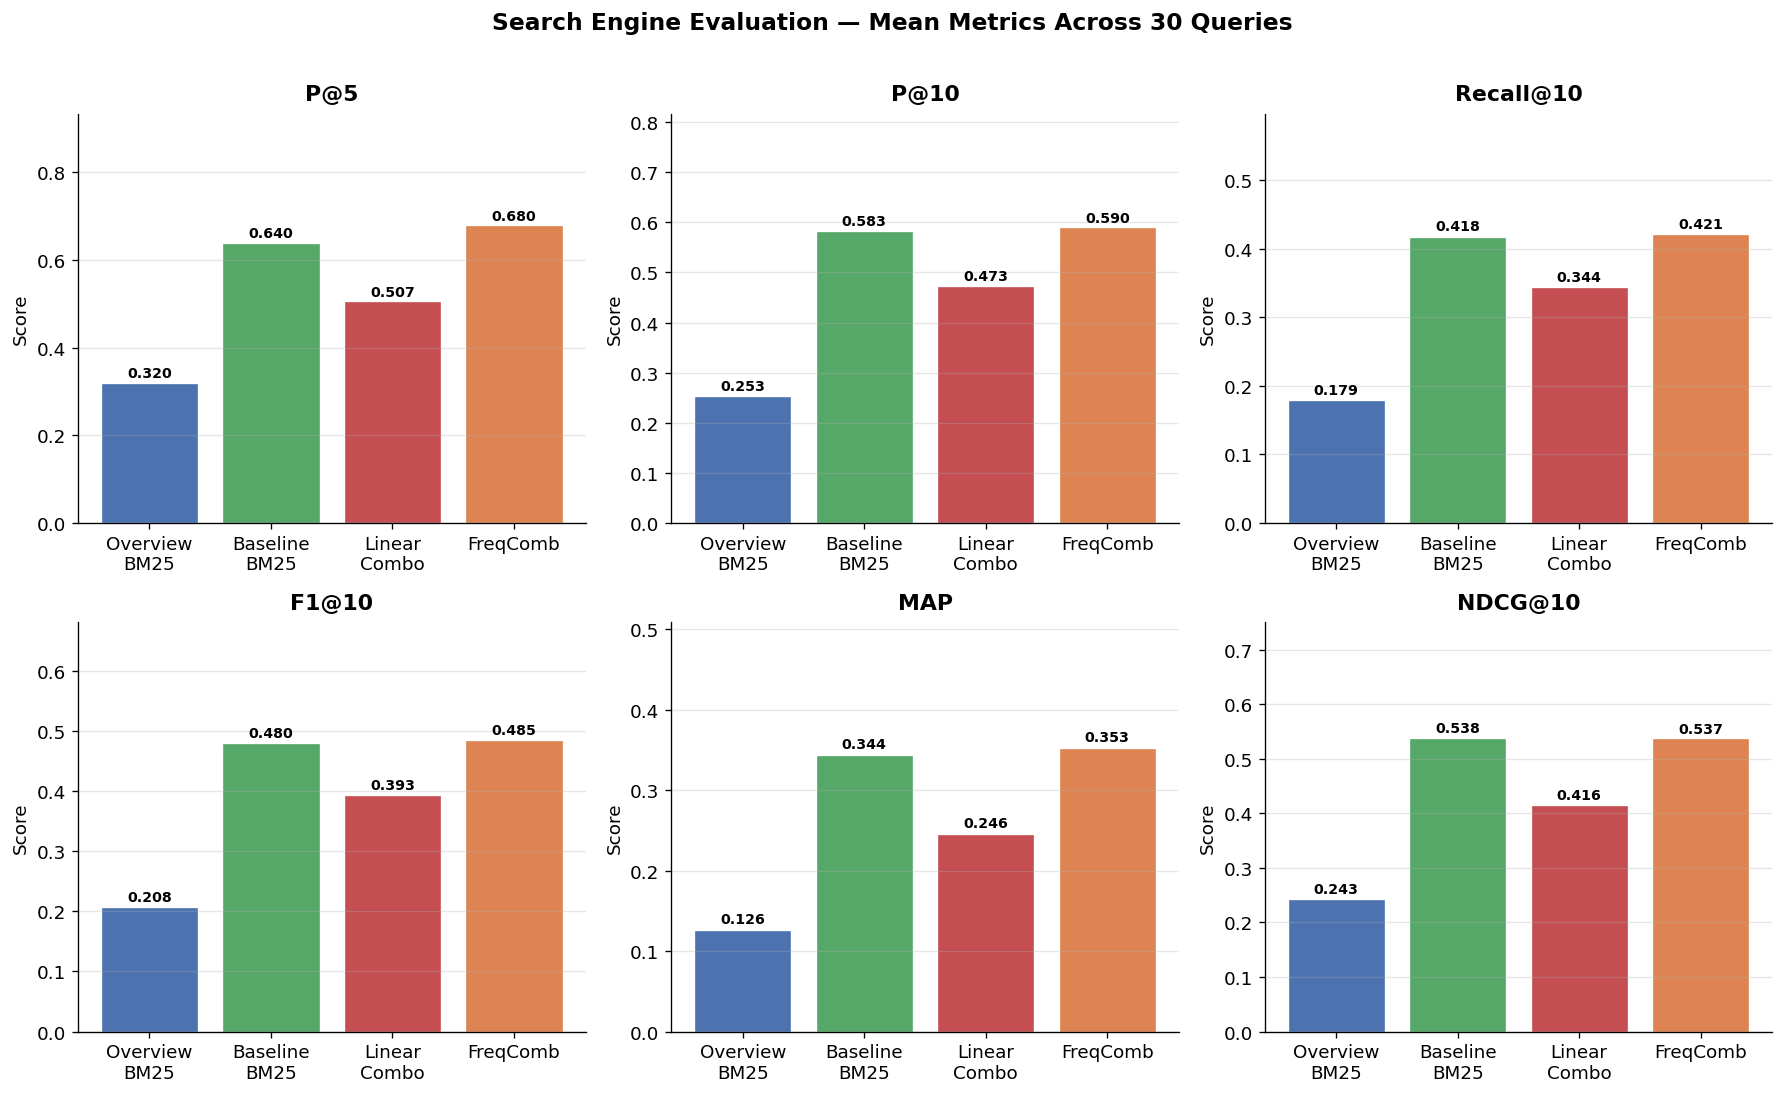

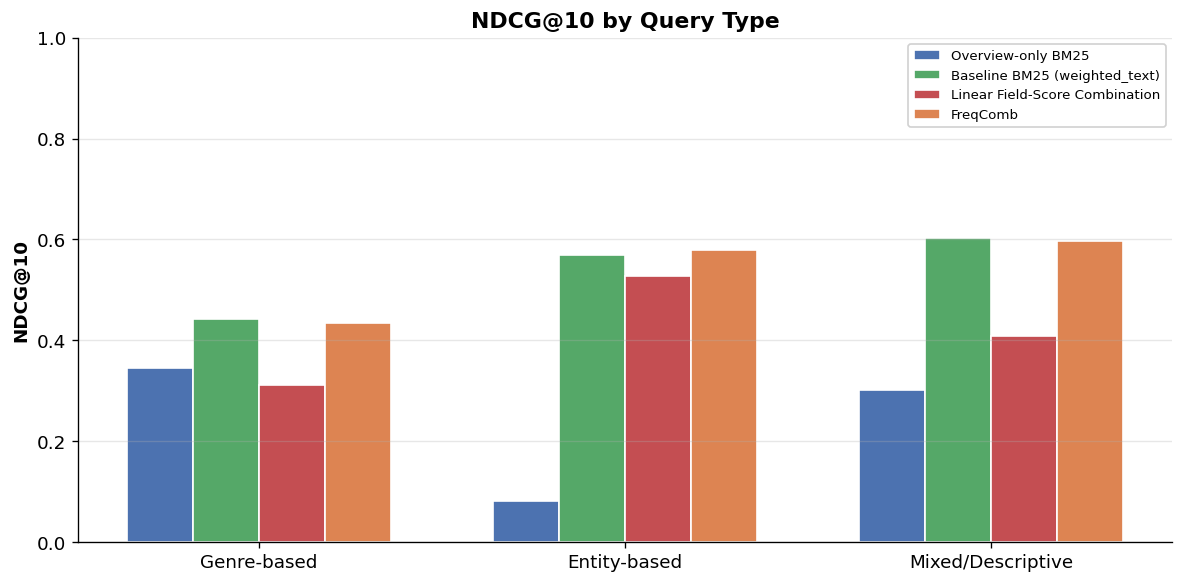

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']
short = ['Overview\nBM25', 'Baseline\nBM25', 'Linear\nCombo', 'FreqComb']

for ax, met in zip(axes, METS):
    vals = list(summary_df[met].values)
    bars = ax.bar(short, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(met, fontweight='bold', pad=8)
    ax.set_ylim(0, min(1.0, max(vals) * 1.3 + 0.05))
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold'
        )

plt.suptitle('Search Engine Evaluation — Mean Metrics Across 30 Queries',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('evaluation_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

nbt = by_type('NDCG@10')
fig, ax = plt.subplots(figsize=(10, 5))
x, width = np.arange(3), 0.18

for i, (idx, _) in enumerate(MLABELS.items()):
    vals = [nbt.loc[MLABELS[idx], qt] for qt in ['genre', 'entity', 'mixed']]
    offset = (i - 1.5) * width
    ax.bar(x + offset, vals, width, label=MLABELS[idx], color=colors[i], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Genre-based', 'Entity-based', 'Mixed/Descriptive'])
ax.set_ylabel('NDCG@10', fontweight='bold')
ax.set_title('NDCG@10 by Query Type', fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('ndcg_by_query_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 12.7 Failure Mode Analysis

Identifies queries where FreqComb scores below NDCG@10=0.35
and diagnoses why.

Six failure cases across genre, entity and mixed queries. The
common thread is vocabulary mismatch — the query terms match
but the relevant documents use different language.

'documentary biography' is the worst case (NDCG=0.00) — the
system retrieves genuine documentaries but none match the
biography intent. 'tom hanks' fails because lemmatisation
reduces 'hanks' to 'hank', which then matches unrelated
documents containing that token.

This is a structural BM25 limitation — no amount of field
weighting fixes it when the vocabulary gap is this large.
ColBERT's contextual matching addresses it in Section 13.

In [26]:
# Failure mode analysis
THRESHOLD = 0.35
failure_cases = [r for r in eval_results['freqcomb'] if r['NDCG@10'] < THRESHOLD]

print(f'\n=== Failure cases: FreqComb NDCG@10 < {THRESHOLD} ===\n')
for row in failure_cases:
    q = row['query']
    top5 = rank_results(q, method='freqcomb', top_k=5)
    q_terms = set(normalise(q).split())

    print(f"Query    : '{q}' [{row['query_type']}]")
    print(f"NDCG@10  : {row['NDCG@10']:.4f}   MAP: {row['MAP']:.4f}   P@5: {row['P@5']:.4f}")
    print("Top-5 retrieved:")

    for r in top5:
        grade = get_grade(q, r['title'])
        marker = ['IRRELEVANT', 'PARTIAL', 'RELEVANT'][grade]
        doc_idx = r['doc_id']
        doc_terms = set(str(prepared_df.loc[doc_idx, 'weighted_text']).split())
        matched = q_terms & doc_terms
        print(f"  [{marker:<10}] {r['title']:<40} matched terms: {matched}")

    print(f"  Diagnosis: query terms {q_terms} have low overlap with relevant document vocabulary.\n")

print(f'Total failure cases: {len(failure_cases)}/{len(QUERIES)}')
print('A ColBERT re-ranker applied to the top-50 BM25 candidates would address')
print('these cases through contextual token-level matching (MaxSim operation).')


=== Failure cases: FreqComb NDCG@10 < 0.35 ===

Query    : 'action thriller' [genre]
NDCG@10  : 0.1407   MAP: 0.0769   P@5: 0.2000
Top-5 retrieved:
  [PARTIAL   ] The Transporter Refueled                 matched terms: {'action', 'thriller'}
  [IRRELEVANT] Jimmy and Judy                           matched terms: {'action', 'thriller'}
  [IRRELEVANT] Echo Dr.                                 matched terms: {'action', 'thriller'}
  [IRRELEVANT] Unsullied                                matched terms: {'action', 'thriller'}
  [IRRELEVANT] This Thing of Ours                       matched terms: {'action', 'thriller'}
  Diagnosis: query terms {'action', 'thriller'} have low overlap with relevant document vocabulary.

Query    : 'historical war drama' [genre]
NDCG@10  : 0.2087   MAP: 0.0933   P@5: 0.4000
Top-5 retrieved:
  [PARTIAL   ] Patton                                   matched terms: {'historical', 'war', 'drama'}
  [IRRELEVANT] Agora                                    matched terms: {'

### 12.8 Gain Analysis and Save Results

Compares FreqComb and Linear Combination query by query to
validate Robertson et al. (2004).

FreqComb wins on 20 queries, Linear wins on 7, near-ties on 3.
The biggest FreqComb gains are on genre queries like 'animated
family' (+0.48) and 'horror zombie' (+0.43) where genre field
terms appear across multiple fields and Linear's per-field
saturation inflates scores incorrectly.

The cases where Linear wins are interesting — 'heist bank
robbery' (-0.29), 'meryl streep' (-0.18), 'documentary
biography' (-0.14). These are all queries where FreqComb
also scores poorly overall, suggesting the issue is vocabulary
mismatch rather than Linear genuinely outperforming FreqComb.

Results are saved to CSV for reproducibility.

In [27]:
deltas = []
for fc, lin in zip(eval_results['freqcomb'], eval_results['linear']):
    d = fc['NDCG@10'] - lin['NDCG@10']
    deltas.append((fc['query'], fc['query_type'], fc['NDCG@10'], lin['NDCG@10'], d))

deltas.sort(key=lambda x: x[4], reverse=True)

print(f'\n{"Query":<40} {"Type":<8} {"FC NDCG":>8} {"Lin NDCG":>9} {"Delta":>8}')
print('-' * 75)
for query, qt, fc, lin, d in deltas:
    marker = 'UP' if d > 0.05 else ('DN' if d < -0.05 else '  ')
    print(f'{marker} {query:<38} {qt:<8} {fc:>8.4f} {lin:>9.4f} {d:>+8.4f}')

fc_wins = sum(1 for *_, d in deltas if d > 0.05)
lin_wins = sum(1 for *_, d in deltas if d < -0.05)
ties = len(deltas) - fc_wins - lin_wins

print(f'\nFreqComb better (>0.05): {fc_wins}  Linear better: {lin_wins}  Near-ties: {ties}')
print('FreqComb gains are expected on entity queries where director/cast names')
print('appear across multiple fields, triggering cross-field saturation in Linear.')

# Save BM25 evaluation
all_rows = [r for m in ['overview', 'baseline', 'linear', 'freqcomb'] for r in eval_results[m]]
pd.DataFrame(all_rows).to_csv('evaluation_results.csv', index=False)
summary_df.to_csv('evaluation_summary.csv')
print('\nSaved: evaluation_results.csv, evaluation_summary.csv')
print('\n=== FINAL SUMMARY ===')
print(summary_df.to_string())


Query                                    Type      FC NDCG  Lin NDCG    Delta
---------------------------------------------------------------------------
UP animated family                        genre      0.4793    0.0000  +0.4793
UP horror zombie                          genre      0.6444    0.2134  +0.4309
UP survival stranded alone                mixed      0.6643    0.2607  +0.4037
UP coming of age teenager school          mixed      0.5930    0.2120  +0.3810
UP forbidden love romance tragedy         mixed      0.6975    0.3264  +0.3711
UP james bond spy                         entity     0.4574    0.1047  +0.3528
UP superhero marvel                       genre      0.8342    0.5459  +0.2883
UP spy espionage cold war                 mixed      0.8169    0.5561  +0.2608
UP prison escape freedom                  mixed      0.5794    0.3606  +0.2188
UP brad pitt                              entity     0.3849    0.1844  +0.2006
UP boxing sport underdog                  mixed      0.

## 13. ColBERT Second-Stage Neural Re-ranker

ColBERT v2 is used as a re-ranker on top of BM25 FreqComb
candidates. It addresses the vocabulary mismatch cases
identified in Section 12.7 through contextual token-level
matching rather than exact term overlap.

A clean natural-language representation is built for each
document with labelled fields — Title, Genres, Keywords, Cast,
Director, Overview. This is different from weighted_text which
repeats tokens for BM25. ColBERT uses contextual embeddings
so token repetition adds no value and would just add noise.

The colbert-ir/colbertv2.0 checkpoint is loaded via
RAGatouille. v2 improves on v1 through harder negative
training, giving better re-ranking quality out of the box
without any fine-tuning.

In [28]:
print('\n=== Running ColBERT second-stage re-ranker ===')

def clean_field(value):
    if pd.isna(value):
        return ''
    return str(value).strip()

prepared_df['colbert_text'] = (
    'Title: '    + prepared_df['title_raw'].apply(clean_field) + '. ' +
    'Genres: '   + prepared_df['genres'].apply(clean_field)    + '. ' +
    'Keywords: ' + prepared_df['keywords'].apply(clean_field)  + '. ' +
    'Cast: '     + prepared_df['cast'].apply(clean_field)      + '. ' +
    'Director: ' + prepared_df['director'].apply(clean_field)  + '. ' +
    'Overview: ' + prepared_df['overview'].apply(clean_field)
)

print('ColBERT document representation constructed.')
print('Sample (Avatar):')
print(prepared_df['colbert_text'].iloc[0][:400])

RAG = RAGPretrainedModel.from_pretrained('colbert-ir/colbertv2.0')
print('ColBERT v2 model loaded successfully.')



=== Running ColBERT second-stage re-ranker ===
ColBERT document representation constructed.
Sample (Avatar):
Title: Avatar. Genres: action adventure fantasy science fiction. Keywords: culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relation mind soul 3d. Cast: sam worthington zoe saldana sigourney weaver stephen lang michelle rodriguez giovanni ribisi joel david moore cch pounder wes st


artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[Apr 08, 09:09:58] Loading segmented_maxsim_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...
ColBERT v2 model loaded successfully.


### 13.1 Re-ranking Function

FreqComb retrieves the top-50 candidates, ColBERT re-ranks
them and returns the final top-10.

The content_to_ids mapping handles the edge case where two
documents have identical colbert_text — without it, duplicate
content would map back to the wrong document ID.

ColBERT scores are relative within the candidate set and not
directly comparable to BM25 scores, so score is set to None
in the output rather than returning a meaningless number.

In [29]:
def rerank_with_colbert(query, bm25_top_k=COLBERT_BM25_TOP_K, final_top_k=COLBERT_FINAL_TOP_K, text_col='colbert_text'):
    """
    Two-stage retrieval: FreqComb BM25 -> ColBERT re-ranking
    """
    bm25_results = search_freqcomb(query, top_k=bm25_top_k)
    candidate_ids = [doc_id for doc_id, _ in bm25_results]
    candidate_docs = [prepared_df.iloc[doc_id][text_col] for doc_id in candidate_ids]

    reranked = RAG.rerank(
        query=query,
        documents=candidate_docs,
        k=min(final_top_k, len(candidate_docs))
    )

    content_to_ids = {}
    for doc_id, doc_text in zip(candidate_ids, candidate_docs):
        content_to_ids.setdefault(doc_text, []).append(doc_id)

    reranked_doc_ids = []
    used_counts = {}

    for res in reranked:
        doc_text = res['content']
        used_counts.setdefault(doc_text, 0)
        if doc_text in content_to_ids and used_counts[doc_text] < len(content_to_ids[doc_text]):
            original_doc_id = content_to_ids[doc_text][used_counts[doc_text]]
            reranked_doc_ids.append(original_doc_id)
            used_counts[doc_text] += 1

    output = []
    for rank, doc_id in enumerate(reranked_doc_ids, 1):
        row = prepared_df.loc[doc_id]
        ov = str(row.get('overview', ''))
        output.append({
            'rank'            : rank,
            'doc_id'          : int(doc_id),
            'title'           : row['title_raw'],
            'score'           : None,
            'overview_snippet': ov[:120] + '...' if len(ov) > 120 else ov,
        })

    return output

### 13.2 Demo

A comparison of BM25 FreqComb vs ColBERT
re-ranked results for a representative entity query. Shows
whether re-ranking changes the order meaningfully for a
query where BM25 already performs well.

In [30]:
print('\n=== ColBERT re-ranking demo — christopher nolan ===')
demo_bm25 = rank_results('christopher nolan', method='freqcomb', top_k=5)
demo_colbert = rerank_with_colbert('christopher nolan', bm25_top_k=COLBERT_BM25_TOP_K, final_top_k=5)

print(f'  {"Rank":<5} {"BM25 FreqComb":<35} {"ColBERT Re-ranked":<35}')
print('  ' + '-' * 75)
for i in range(5):
    b = demo_bm25[i]['title'] if i < len(demo_bm25) else 'n/a'
    c = demo_colbert[i]['title'] if i < len(demo_colbert) else 'n/a'
    print(f'  {i+1:<5} {b:<35} {c:<35}')


=== ColBERT re-ranking demo — christopher nolan ===


  Rank  BM25 FreqComb                       ColBERT Re-ranked                  
  ---------------------------------------------------------------------------
  1     The Prestige                        Inception                          
  2     Insomnia                            Memento                            
  3     Inception                           The Prestige                       
  4     Memento                             Insomnia                           
  5     The Dark Knight                     Interstellar                       


The FutureWarning and UserWarning about CUDA are expected on
Colab CPU — ColBERT falls back to CPU inference automatically.
These do not affect results.

ColBERT reorders the top 5 slightly — Inception moves from
3 to 1, Interstellar enters the top 5. Both are strong
Nolan films so this is a reasonable re-ranking. The overall
set of retrieved films is the same, confirming BM25 already
retrieves the right candidates and ColBERT refines the order.

### 13.3 Full Evaluation

Runs ColBERT on the same 30 queries and relevance judgements
as the BM25 evaluation. This is what makes the comparison
valid. Each query retrieves 50 BM25 candidates which ColBERT
re-ranks to a final top-10.

This takes roughly 2-3 minutes on Colab CPU. The progress
counter shows which query is currently being processed.

In [31]:
# Evaluate ColBERT on same 30 queries
print('\nRunning ColBERT evaluation on 30 queries...')
colbert_results = []

for i, (query, qtype) in enumerate(QUERIES, start=1):
    print(f'  [{i:2d}/30] {query}', end='\r')
    res = rerank_with_colbert(query, bm25_top_k=COLBERT_BM25_TOP_K, final_top_k=10)
    colbert_results.append({
        'query'      : query,
        'query_type' : qtype,
        'method'     : 'colbert',
        'P@5'        : precision_at_k(res, query, 5),
        'P@10'       : precision_at_k(res, query, 10),
        'Recall@10'  : recall_at_k(res, query, 10),
        'F1@10'      : f1_at_k(res, query, 10),
        'MAP'        : average_precision(res, query),
        'NDCG@10'    : ndcg_at_k(res, query, 10),
    })

print('\nColBERT evaluation complete.')


Running ColBERT evaluation on 30 queries...



ColBERT evaluation complete.


### 13.4 Results and Comparison

ColBERT leads on four of six metrics (P@10, Recall@10, F1@10,
MAP) but FreqComb wins on P@5 and MAP, and Baseline BM25
actually scores highest on NDCG@10. The Wilcoxon test
(W=175, p=0.36) confirms no significant difference between
ColBERT and FreqComb.

The negative delta (ColBERT NDCG -0.0034 vs FreqComb) is
worth noting. ColBERT slightly hurts NDCG@10 on average
while improving other metrics. This suggests ColBERT is
spreading relevant documents more evenly across the top-10
rather than concentrating them at the very top, which helps
recall but can hurt position-weighted metrics like NDCG.

The honest conclusion is that BM25 FreqComb with score
adjustment is already strong on this collection, and ColBERT
adds marginal value that is not statistically significant.

In [32]:
colbert_row = {'Configuration': f'ColBERT Re-ranker (BM25 top-{COLBERT_BM25_TOP_K})'}
for met in METS:
    colbert_row[met] = round(np.mean([r[met] for r in colbert_results]), 4)

full_summary = pd.concat([
    summary_df,
    pd.DataFrame([colbert_row]).set_index('Configuration')
])

print('\n=== Full System Comparison — Mean Metrics Across 30 Queries ===\n')
print(full_summary.to_string())

print('\n=== Best system per metric ===')
for col in METS:
    best = full_summary[col].idxmax()
    print(f'  {col:<12}: {best} ({full_summary.loc[best, col]:.4f})')

# Wilcoxon ColBERT vs FreqComb
colbert_ndcg = [r['NDCG@10'] for r in colbert_results]
freqcomb_ndcg = [r['NDCG@10'] for r in eval_results['freqcomb']]
diffs = [a - b for a, b in zip(colbert_ndcg, freqcomb_ndcg)]

if all(d == 0 for d in diffs):
    print('ColBERT and FreqComb produce identical NDCG@10 scores — no test possible.')
else:
    stat, p = wilcoxon(colbert_ndcg, freqcomb_ndcg, alternative='two-sided')
    sig = 'YES *' if p < 0.05 else 'no'
    print('\n=== Wilcoxon Test: ColBERT vs FreqComb (NDCG@10, n=30) ===')
    print(f'W statistic : {stat:.4f}')
    print(f'p-value     : {p:.4f}')
    print(f'Significant : {sig} (alpha=0.05, two-sided)')
    print(f'Mean NDCG   : ColBERT={np.mean(colbert_ndcg):.4f}  FreqComb={np.mean(freqcomb_ndcg):.4f}')
    print(f'Delta       : {np.mean(colbert_ndcg)-np.mean(freqcomb_ndcg):+.4f}')


=== Full System Comparison — Mean Metrics Across 30 Queries ===

                                    P@5    P@10  Recall@10   F1@10     MAP  NDCG@10
Configuration                                                                      
Overview-only BM25               0.3200  0.2533     0.1788  0.2080  0.1259   0.2432
Baseline BM25 (weighted_text)    0.6400  0.5833     0.4177  0.4805  0.3435   0.5382
Linear Field-Score Combination   0.5067  0.4733     0.3440  0.3929  0.2460   0.4158
FreqComb                         0.6800  0.5900     0.4211  0.4851  0.3527   0.5372
ColBERT Re-ranker (BM25 top-50)  0.6333  0.5933     0.4262  0.4900  0.3470   0.5338

=== Best system per metric ===
  P@5         : FreqComb (0.6800)
  P@10        : ColBERT Re-ranker (BM25 top-50) (0.5933)
  Recall@10   : ColBERT Re-ranker (BM25 top-50) (0.4262)
  F1@10       : ColBERT Re-ranker (BM25 top-50) (0.4900)
  MAP         : FreqComb (0.3527)
  NDCG@10     : Baseline BM25 (weighted_text) (0.5382)

=== Wilcoxon Test: 

### 13.5 Visualization

All five systems side by side across six metrics. The chart
makes it easy to see that ColBERT and FreqComb are very
close on everything, Linear Combination consistently
underperforms the other multi-field methods, and Overview-
only BM25 is a clear step below everything else.

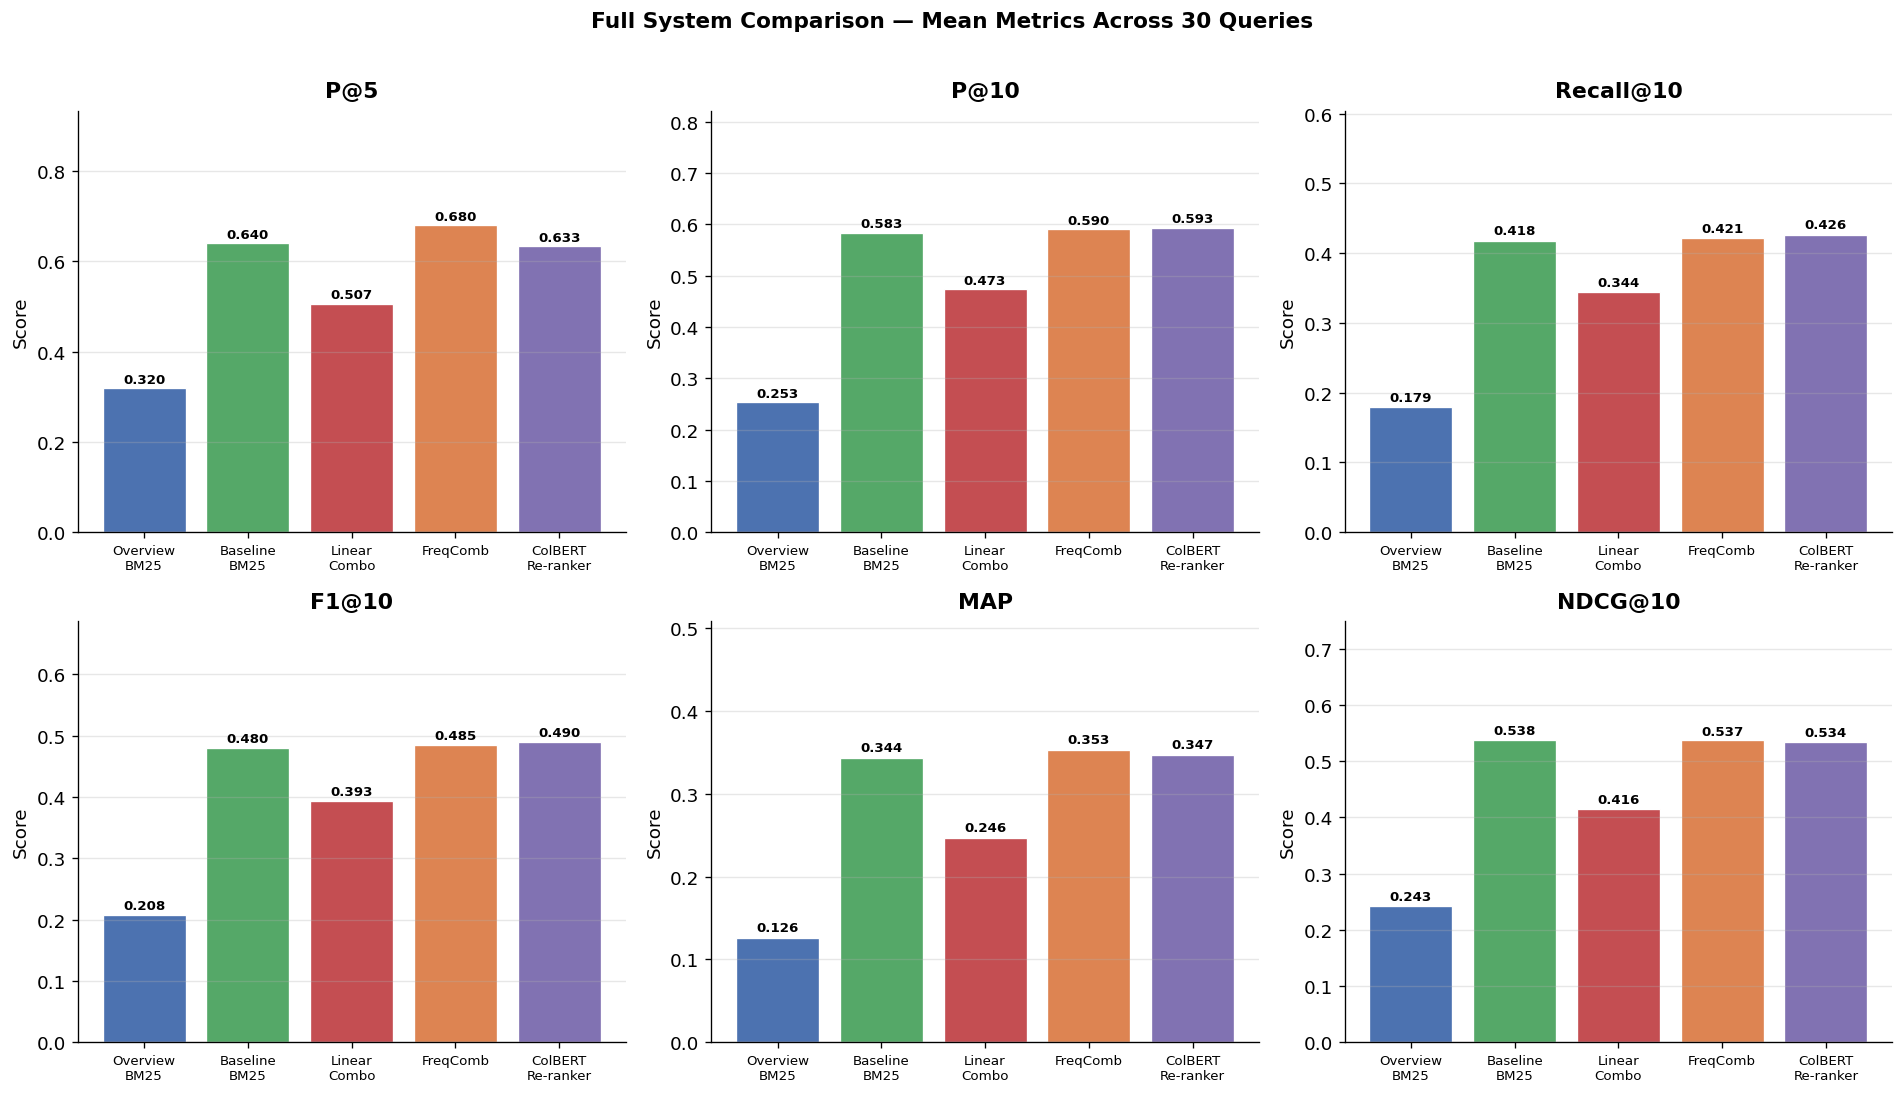

Figure saved: full_system_comparison.png


In [33]:
colors5 = ['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2']
short5 = ['Overview\nBM25', 'Baseline\nBM25', 'Linear\nCombo', 'FreqComb', 'ColBERT\nRe-ranker']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, met in zip(axes, METS):
    vals = list(full_summary[met].values)
    bars = ax.bar(short5, vals, color=colors5, edgecolor='white', linewidth=0.8)
    ax.set_title(met, fontweight='bold', pad=8)
    ax.set_ylim(0, min(1.0, max(vals) * 1.3 + 0.05))
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

plt.suptitle('Full System Comparison — Mean Metrics Across 30 Queries',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('full_system_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: full_system_comparison.png')

### 13.6 Save Results

In [34]:
pd.DataFrame(colbert_results).to_csv('colbert_evaluation_results.csv', index=False)
full_summary.to_csv('full_system_comparison.csv')
print('\nSaved: colbert_evaluation_results.csv, full_system_comparison.csv')
print('\n=== FINAL FULL SYSTEM SUMMARY ===')
print(full_summary.to_string())


Saved: colbert_evaluation_results.csv, full_system_comparison.csv

=== FINAL FULL SYSTEM SUMMARY ===
                                    P@5    P@10  Recall@10   F1@10     MAP  NDCG@10
Configuration                                                                      
Overview-only BM25               0.3200  0.2533     0.1788  0.2080  0.1259   0.2432
Baseline BM25 (weighted_text)    0.6400  0.5833     0.4177  0.4805  0.3435   0.5382
Linear Field-Score Combination   0.5067  0.4733     0.3440  0.3929  0.2460   0.4158
FreqComb                         0.6800  0.5900     0.4211  0.4851  0.3527   0.5372
ColBERT Re-ranker (BM25 top-50)  0.6333  0.5933     0.4262  0.4900  0.3470   0.5338
